# ANÁLISIS EXPLORATORIO DE DATOS (EDA)



# 1. Setup e importaciones

En esta sección se importan las librerías necesarias para el desarrollo del análisis de datos, incluyendo herramientas para manipulación, visualización y análisis estadístico. Se configura también el entorno de trabajo, garantizando que los paquetes estén correctamente instalados.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 2. Carga de los datos

El set de datos que se utilizará corresponde a los registros históricos de la convocatoria del programa Becas Talento de la Universidad EAFIT, comprendidos entre los semestres 2023-2 y 2025-1. Este archivo contiene información académica, socioeconómica y demográfica de los postulantes.

In [5]:
#Carga y lectura del dataset
archivo = "/content/Datos_Trabajo_de_grado.xlsx"
df = pd.read_excel(archivo)
print(df.head())


  Semestre                        Nombre Tipo doc  #documento Resultado Final  \
0   2025-1     Sebastian Builes Restrepo       CC  1000660285          Negada   
1   2025-1  Luis Jerónimo Valencia Mejía       CC  1023524022          Negada   
2   2025-1         Madelyn Ortiz Quiceno       CC  1018224236        Aprobada   
3   2025-1   MARIA CAMILA TORRES PENAGOS       CC  1105360983          Negada   
4   2025-1        juan jose lopez macias       CC  1000762492          Negada   

   % beca talento final aprobada Pregrado final aprobado talento  \
0                            NaN                             NaN   
1                            NaN                             NaN   
2                            0.7          Ingeniería de Procesos   
3                            NaN                             NaN   
4                            NaN                             NaN   

   Confirma #  doc.  Edad al postularse Lugar de nacimiento  ... Carro Marca  \
0        1000660285     

# 3. Inspección iniciala del dataset

En esta etapa se realiza una primera exploración del conjunto de datos, verificando su estructura general (filas, columnas y tipos de variables). Además, se identifican las variables numéricas y categóricas, y se cuantifica la presencia de valores nulos o ausentes que puedan afectar el análisis posterior.

In [6]:
print(f"\nNúmero de filas y columnas: {df.shape}")
print("\nResumen de estructura del dataset:")
df.info()



Número de filas y columnas: (5890, 140)

Resumen de estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5890 entries, 0 to 5889
Columns: 140 entries, Semestre to Observaciones
dtypes: float64(3), int64(3), object(134)
memory usage: 6.3+ MB


In [7]:
# Identificar columnas numéricas y categóricas
variables_numericas = df.select_dtypes(include=["number"]).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:", variables_numericas)
print("\nVariables categóricas:", variables_categoricas)


Variables numéricas: ['#documento', '% beca talento final aprobada', 'Confirma #  doc.', 'Edad al postularse', 'Año graduación', 'Con cuántas personas vives actualmente']

Variables categóricas: ['Semestre', 'Nombre', 'Tipo doc', 'Resultado Final', 'Pregrado final aprobado talento', 'Lugar de nacimiento', 'Nació en el exterior', 'Sexo biológico', 'Estado civil', 'Víctima del conflicto', 'Víctima de desplazamiento', 'Discapacidad física o psicosocial', 'Grupo étnico', 'Aspirante tiene hijos', '¿Marcardor social?', '¿Alguna otra condición?', 'Barrio', 'Dirección actual', 'Teléfono', 'Celular', 'Correo ', 'Dpto de Residencia', 'Mpio de residencia', 'Puntaje ICFES', 'Año ICFES', 'N° registro ICFES', 'Nombre colegio', 'Tipo colegio', 'Dpto IE', 'Depto IE Otro', 'Mpio IE', 'Act. Artísticas', 'Tiempo', 'Act. deportivas', 'Tiempo.1', 'Act. liderazgo', 'Tiempo.2', ' Trabajo social o comunitario ', 'Tiempo.3', 'Otras actividades', 'Tiempo.4', 'Física 10°', 'Física 11°', 'Química 10°', 'Química 1

# 4. Análisis de nulos y tipos

Se analizan los valores faltantes por columna para determinar su magnitud y distribución. A partir de este diagnóstico se definen estrategias de tratamiento como imputación o eliminación, según la relevancia y frecuencia de los datos faltantes. Esta revisión es clave para garantizar la consistencia del conjunto de datos.

In [8]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

nulos_filtrados = nulos[nulos > 0].sort_values(ascending=False)
porcentaje_filtrado = porcentaje_nulos[nulos > 0].sort_values(ascending=False)

print("\nValores nulos por columna:")
for col in nulos_filtrados.index:
    print(f"{col}: {nulos_filtrados[col]} nulos ({porcentaje_filtrado[col]:.2f}%)")



Valores nulos por columna:
Depto IE Otro: 5871 nulos (99.68%)
Nació en el exterior: 5720 nulos (97.11%)
Fam5 Inst/Empresa: 5604 nulos (95.14%)
Otro Modelo: 5590 nulos (94.91%)
Fam5 Ingresos: 5576 nulos (94.67%)
Suficiencia en el idioma inglés: 5558 nulos (94.36%)
Fam5 Cargo/Actividad: 5533 nulos (93.94%)
Fam4 Institución/Empresa: 5504 nulos (93.45%)
Fam5 Parentesc: 5504 nulos (93.45%)
Fam5 Edad: 5498 nulos (93.34%)
Fam4 Ingresos: 5460 nulos (92.70%)
Fam4 Cargo/Actividad: 5403 nulos (91.73%)
Camión Modelo: 5403 nulos (91.73%)
Forma de pago: 5385 nulos (91.43%)
Camión Valor Comercial: 5379 nulos (91.32%)
Otro Valor Comercial: 5345 nulos (90.75%)
Fam4 Parentesco: 5323 nulos (90.37%)
Fam4 Edad: 5319 nulos (90.31%)
Fam5 Nombres: 5309 nulos (90.14%)
Tiempo.4: 5291 nulos (89.83%)
Fam3 Institución/empresa: 5251 nulos (89.15%)
Valor mensual de tus ingresos: 5174 nulos (87.84%)
Actividad por la cual recibes ingresos: 5174 nulos (87.84%)
Camión Marca: 5169 nulos (87.76%)
Fam3 Ingresos: 5169 nulo

<Axes: >

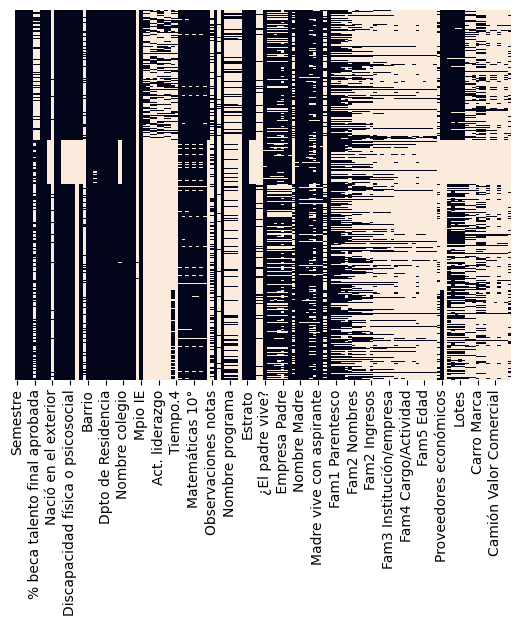

In [9]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)


# 5. Análisis descriptivo por semestres

Esta sección presenta una caracterización general de los postulantes al programa de Becas Talento, incluyendo aspectos demográficos como edad, género y lugar de residencia.
Se analizan además las distribuciones por semestre y los resultados del proceso de selección, permitiendo identificar tendencias, variaciones entre cohortes y composición poblacional del conjunto de datos.

In [10]:
agrupado = df.groupby("Semestre").agg({
    "Resultado Final": lambda x: x.value_counts().to_dict(),
    "% beca talento final aprobada": lambda x: x.value_counts().to_dict(),
    "¿Marcardor social?": lambda x: x.value_counts().to_dict(),
    "Dpto de Residencia": lambda x: x.value_counts().to_dict(),
    "Puntaje ICFES": "count",
    "Año ICFES": "count",
    "Estrato": lambda x: x.value_counts().to_dict()
})

print(agrupado)


                            Resultado Final  \
Semestre                                      
2023-2     {'Aprobada': 400, 'Negada': 303}   
2024-1    {'Negada': 1181, 'Aprobada': 509}   
2024-2     {'Negada': 808, 'Aprobada': 612}   
2025-1    {'Negada': 1487, 'Aprobada': 590}   

                              % beca talento final aprobada  \
Semestre                                                      
2023-2    {0.4: 117, 0.5: 86, 0.7: 70, 1.0: 49, 0.6: 42,...   
2024-1    {0.4: 226, 0.5: 81, 0.7: 58, 0.6: 58, 0.8: 39,...   
2024-2    {0.4: 280, 0.5: 161, 0.6: 60, 0.7: 47, 0.8: 35...   
2025-1    {0.4: 271, 0.5: 93, 0.6: 74, 0.7: 49, 0.8: 38,...   

               ¿Marcardor social?  \
Semestre                            
2023-2                         {}   
2024-1    {'NO': 1324, 'SI': 366}   
2024-2    {'NO': 1135, 'SI': 285}   
2025-1    {'NO': 1723, 'SI': 354}   

                                         Dpto de Residencia  Puntaje ICFES  \
Semestre                             

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

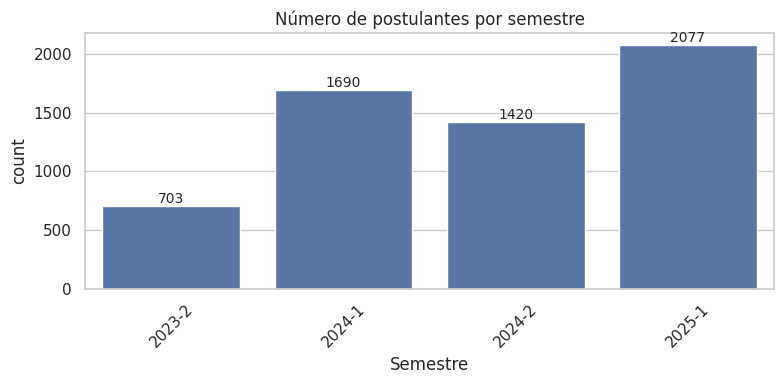

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

orden_semestres = ["2023-2", "2024-1", "2024-2", "2025-1"]
ax = sns.countplot(x="Semestre", data=df, order=orden_semestres)

plt.title("Número de postulantes por semestre")
plt.xticks(rotation=45)
plt.tight_layout()


for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{int(altura)}',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=10)

plt.show()


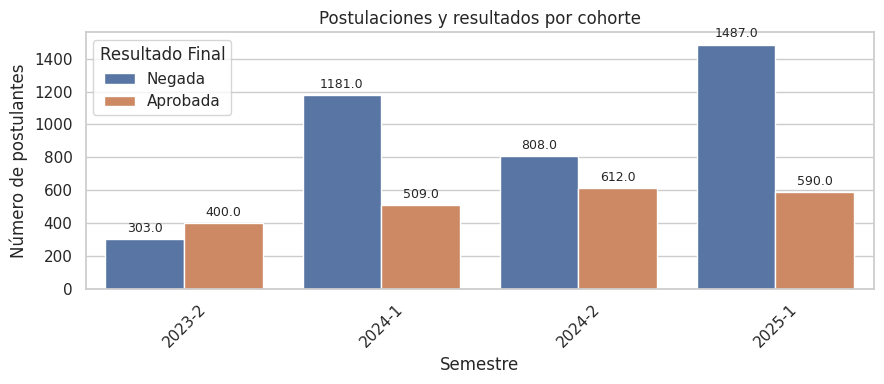

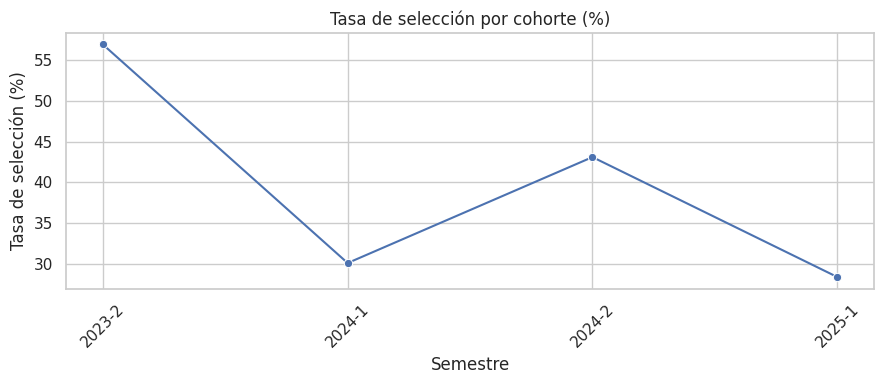

In [13]:
orden_semestres = sorted(df["Semestre"].dropna().unique(),
                         key=lambda s: (int(str(s).split('-')[0]), str(s).split('-')[1]))

tmp = df.copy()
tmp["es_aprobada"] = (tmp["Resultado Final"].astype(str).str.upper().str.contains("APRO")).astype(int)

tasas = (tmp.groupby("Semestre", as_index=False)
            .agg(postulantes=("Resultado Final","size"),
                 aprobadas=("es_aprobada","sum")))
tasas["tasa_seleccion"] = 100 * tasas["aprobadas"] / tasas["postulantes"]

# Gráfico 1: barras con totales por cohorte (conteos)
plt.figure(figsize=(9,4))
ax = sns.countplot(data=df, x="Semestre", hue="Resultado Final", order=orden_semestres)
plt.title("Postulaciones y resultados por cohorte")
plt.ylabel("Número de postulantes")
plt.xlabel("Semestre")
plt.xticks(rotation=45)

# Anotar totales encima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height}", (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords="offset points")

plt.tight_layout()
plt.show()

# Gráfico 2: línea con la tasa de selección (%) por cohorte
plt.figure(figsize=(9,4))
sns.lineplot(data=tasas.sort_values("Semestre", key=lambda s: s.map({k:i for i,k in enumerate(orden_semestres)})),
             x="Semestre", y="tasa_seleccion", marker="o")
plt.title("Tasa de selección por cohorte (%)")
plt.ylabel("Tasa de selección (%)")
plt.xlabel("Semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



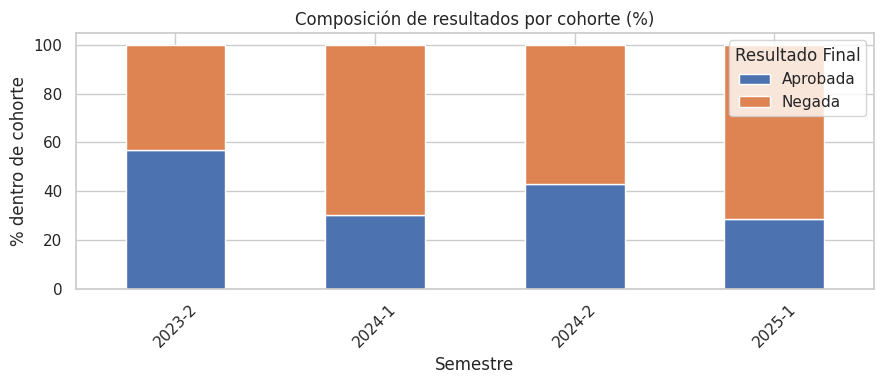

In [14]:
tabla = pd.crosstab(df["Semestre"], df["Resultado Final"])
tabla = tabla.reindex(index=orden_semestres)
(tabla.div(tabla.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, figsize=(9,4))
plt.title("Composición de resultados por cohorte (%)")
plt.ylabel("% dentro de cohorte")
plt.xlabel("Semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-698479867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


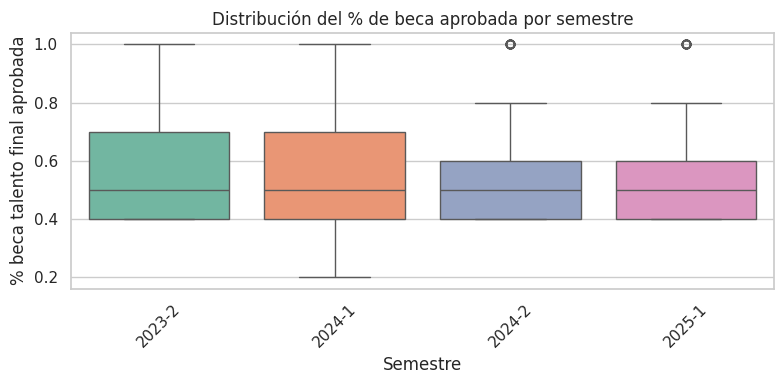

In [15]:
plt.figure(figsize=(8, 4))

palette_colores = sns.color_palette("Set2", n_colors=len(orden_semestres))

sns.boxplot(
    x="Semestre",
    y="% beca talento final aprobada",
    data=df,
    order=orden_semestres,
    palette=palette_colores
)

plt.title("Distribución del % de beca aprobada por semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


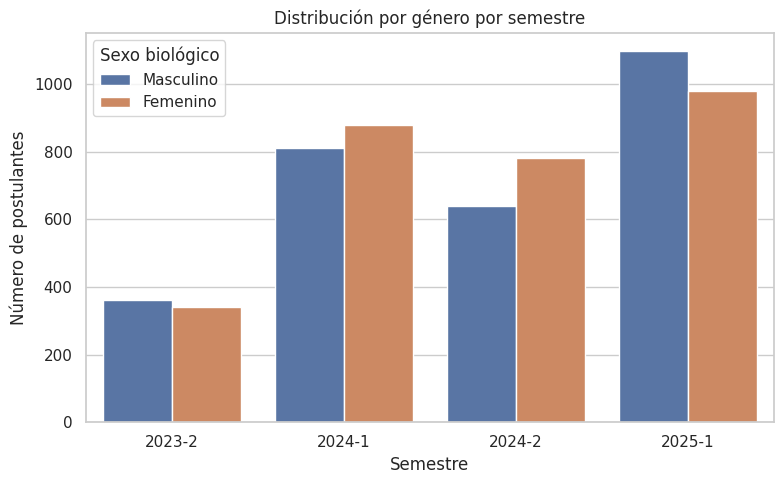

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Semestre", hue="Sexo biológico", order=sorted(df["Semestre"].unique()))
plt.title("Distribución por género por semestre")
plt.ylabel("Número de postulantes")
plt.xlabel("Semestre")
plt.legend(title="Sexo biológico")
plt.tight_layout()
plt.show()


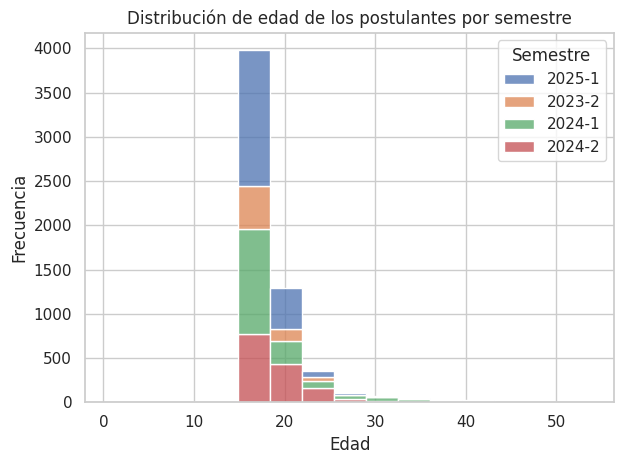

In [17]:
sns.histplot(data=df[df["Edad al postularse"] > 0], x="Edad al postularse", hue="Semestre", bins=15, multiple="stack")
plt.title("Distribución de edad de los postulantes por semestre")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


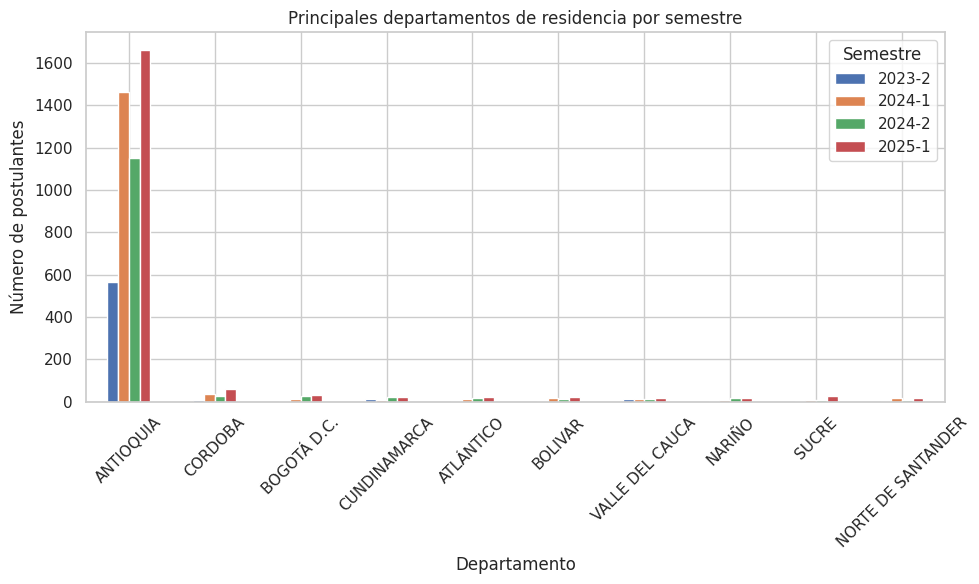

In [18]:
# Estandarizar el texto de la columna "Dpto de Residencia"
df["Dpto de Residencia"] = df["Dpto de Residencia"].str.upper().str.strip()

# Luego puedes volver a graficar
deptos = df.groupby("Dpto de Residencia")["Semestre"].value_counts().unstack().fillna(0)
top_deptos = deptos.sum(axis=1).sort_values(ascending=False).head(10).index
deptos.loc[top_deptos].plot(kind="bar", figsize=(10, 6))

plt.title("Principales departamentos de residencia por semestre")
plt.ylabel("Número de postulantes")
plt.xlabel("Departamento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 6. Análisis académico y socioeconómico

Se examinan las variables académicas y socioeconómicas que pueden influir en la asignación de becas, tales como el puntaje y año de las pruebas ICFES, los ingresos familiares, y el semestre de postulación. A través de visualizaciones y estadísticas descriptivas se identifican patrones y diferencias entre cohortes.

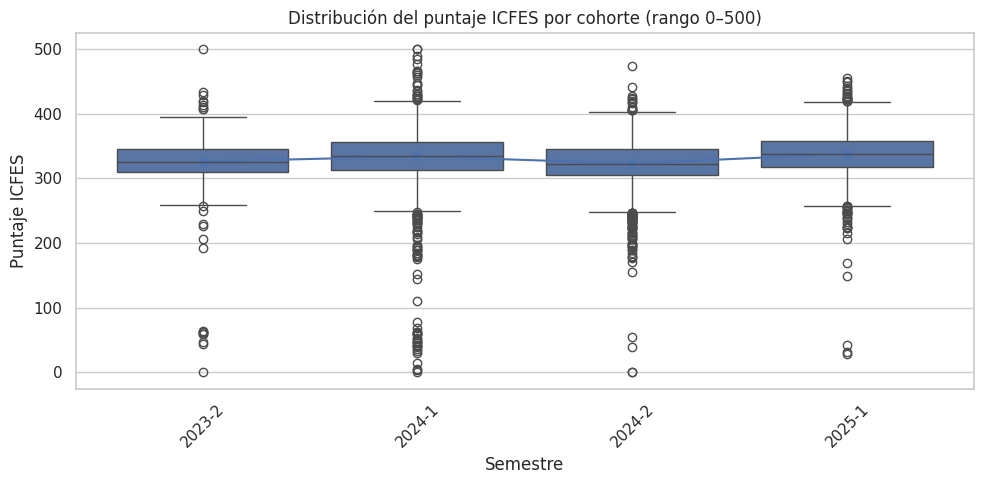

In [19]:
# Limpieza ICFES al rango válido 0–500
df_icfes = df.copy()
df_icfes["Puntaje ICFES"] = pd.to_numeric(df_icfes["Puntaje ICFES"], errors="coerce")
df_icfes = df_icfes[df_icfes["Puntaje ICFES"].between(0, 500)]

plt.figure(figsize=(10,5))
ax = sns.boxplot(x="Semestre", y="Puntaje ICFES", data=df_icfes, order=orden_semestres)
plt.title("Distribución del puntaje ICFES por cohorte (rango 0–500)")
plt.xticks(rotation=45)

# Medianas por cohorte (línea)
medianas = (df_icfes.groupby("Semestre")["Puntaje ICFES"]
                     .median().reindex(orden_semestres))
plt.plot(range(len(orden_semestres)), medianas.values, marker="o")
plt.tight_layout()
plt.show()







/tmp/ipython-input-2764114640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Resultado Final", y="Promedio notas 11", palette="Set2")


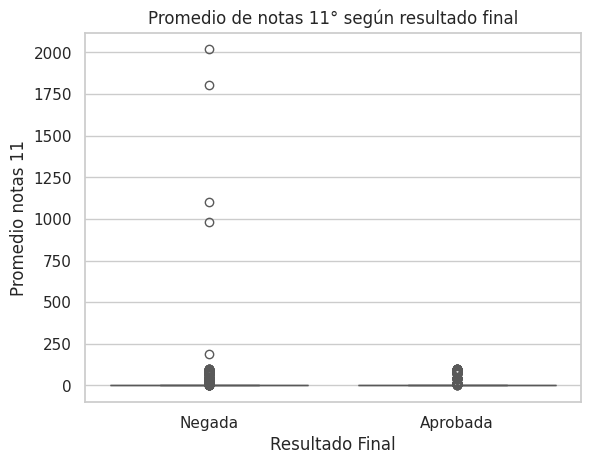

In [20]:
notas_cols = ["Física 11°", "Química 11°", "Matemáticas 11°", "Lenguaje/Español 11°"]
df["Promedio notas 11"] = df[notas_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
sns.boxplot(data=df, x="Resultado Final", y="Promedio notas 11", palette="Set2")
plt.title("Promedio de notas 11° según resultado final")
plt.show()


Se identificó que las calificaciones de presentan formatos mixtos, combinando valores numéricos y texto.

Esta inconsistencia impide calcular un promedio confiable en esta fase, por lo que la normalización y estandarización de estas variables se realizará posteriormente en la etapa de ingeniería de características.

In [21]:
df["Total ingresos padres"] = pd.to_numeric(df["Total ingresos padres"], errors="coerce")
df_ingresos = df[df["Total ingresos padres"].notnull()]


/tmp/ipython-input-1109351170.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


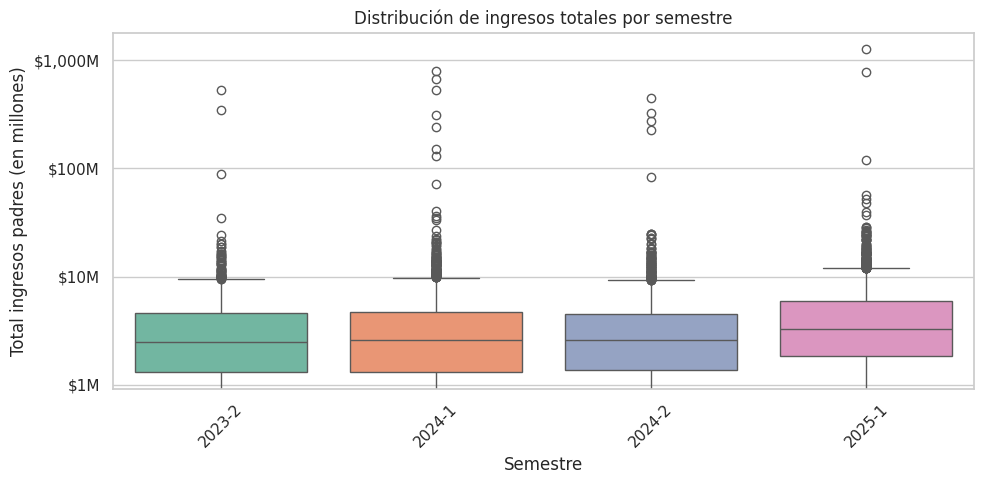

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(10, 5))

# Boxplot con orden y colores personalizados
orden_semestres = ["2023-2", "2024-1", "2024-2", "2025-1"]
palette = sns.color_palette("Set2", len(orden_semestres))

sns.boxplot(
    x="Semestre",
    y="Total ingresos padres",
    data=df_ingresos,
    order=orden_semestres,
    palette=palette,
    ax=ax
)

# Escala logarítmica
ax.set_yscale("log")

# Formateo del eje Y en millones
formatter = ticker.FuncFormatter(lambda x, _: f"${int(x/1e6):,}M")
ax.yaxis.set_major_formatter(formatter)

# Personalización
ax.set_title("Distribución de ingresos totales por semestre")
ax.set_ylabel("Total ingresos padres (en millones)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



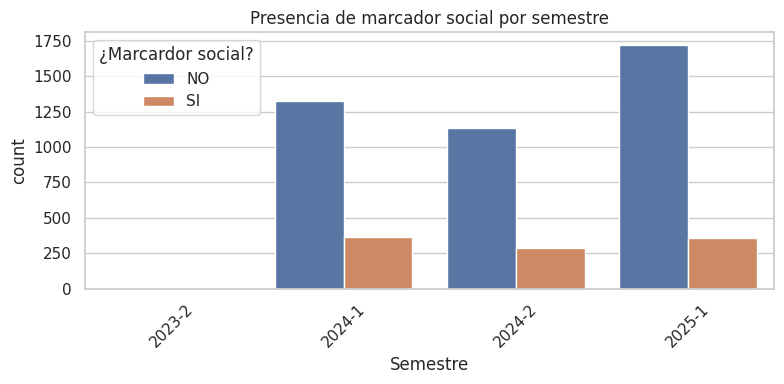

In [23]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x="Semestre", hue="¿Marcardor social?", data=df, order=orden_semestres)
plt.title("Presencia de marcador social por semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
for col in variables_numericas:
    print(f"\n>> {col}")
    print(df.groupby("Resultado Final")[col].mean())




>> #documento
Resultado Final
Aprobada    1.029583e+09
Negada      1.020789e+09
Name: #documento, dtype: float64

>> % beca talento final aprobada
Resultado Final
Aprobada    0.542671
Negada           NaN
Name: % beca talento final aprobada, dtype: float64

>> Confirma #  doc.
Resultado Final
Aprobada    1.027692e+09
Negada      1.022585e+09
Name: Confirma #  doc., dtype: float64

>> Edad al postularse
Resultado Final
Aprobada    18.173214
Negada      19.346114
Name: Edad al postularse, dtype: float64

>> Año graduación
Resultado Final
Aprobada    2021.496921
Negada      2019.542472
Name: Año graduación, dtype: float64

>> Con cuántas personas vives actualmente
Resultado Final
Aprobada    2.870836
Negada      3.025892
Name: Con cuántas personas vives actualmente, dtype: float64


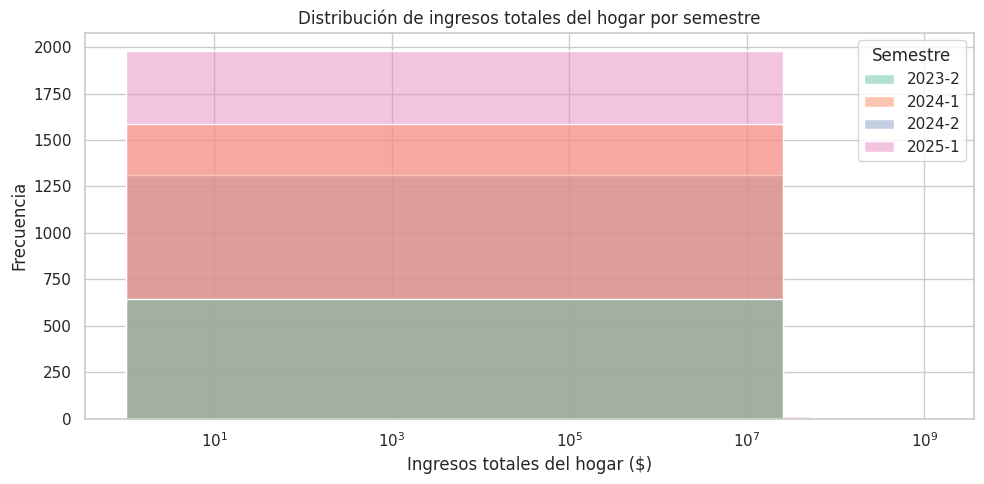

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Total ingresos padres"] = pd.to_numeric(df["Total ingresos padres"], errors="coerce")
df_ingresos = df[df["Total ingresos padres"] > 0]

orden_semestres = ["2023-2", "2024-1", "2024-2", "2025-1"]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_ingresos,
    x="Total ingresos padres",
    hue="Semestre",
    multiple="layer",
    bins=50,
    palette="Set2",
    hue_order=orden_semestres
)

plt.title("Distribución de ingresos totales del hogar por semestre")
plt.xlabel("Ingresos totales del hogar ($)")
plt.ylabel("Frecuencia")
plt.xscale("log")
plt.tight_layout()
plt.show()


# 7. Correlaciones numéricas

En esta sección se calcula la correlación entre variables numéricas relevantes del conjunto de datos para identificar posibles relaciones lineales y redundancias.
Se incluyen coeficientes de Pearson y medidas de asociación eta² con la variable objetivo.
Este paso permite seleccionar variables con mayor capacidad explicativa y descartar aquellas que aportan información duplicada.

In [26]:
import numpy as np

def calcular_eta_squared(df, num_col, cat_col):
    grupos = df.groupby(cat_col)[num_col]
    medias_grupo = grupos.mean()
    media_total = df[num_col].mean()
    ss_between = sum(grupos.count() * (medias_grupo - media_total) ** 2)
    ss_total = sum((df[num_col] - media_total) ** 2)
    return ss_between / ss_total if ss_total > 0 else np.nan

# Aplicar eta squared para cada numérica
print("\nCorrelación eta² de variables numéricas con Resultado Final:")
for col in variables_numericas:
    eta = calcular_eta_squared(df, col, "Resultado Final")
    if not np.isnan(eta):
        print(f"{col}: η² = {eta:.3f}")



Correlación eta² de variables numéricas con Resultado Final:
#documento: η² = 0.001
Confirma #  doc.: η² = 0.000
Edad al postularse: η² = 0.025
Año graduación: η² = 0.000


In [27]:
# Variables numéricas útiles
variables_relevantes = [
    "% beca talento final aprobada",
    "Edad al postularse",
    "Puntaje ICFES",
    "Año ICFES",
    "Año graduación",
    "Total ingresos padres",
    "Con cuántas personas vives actualmente"
]


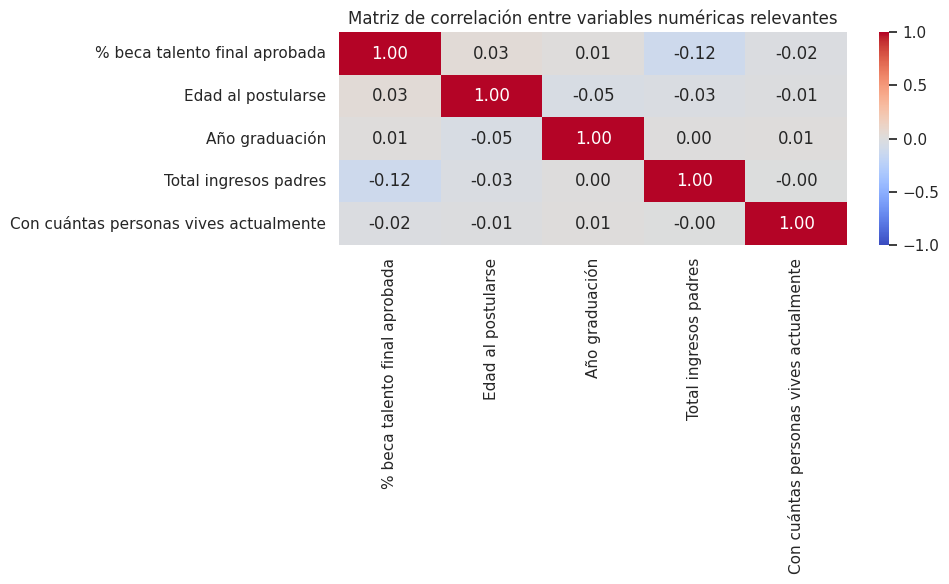

In [28]:
# Correlación solo con variables numéricas dentro del conjunto relevante
df_corr = df[variables_relevantes].select_dtypes(include=["number"])

# Calcular la matriz de correlación
corr = df_corr.corr()

# Visualización
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables numéricas relevantes")
plt.tight_layout()
plt.show()


Se observó que las variables “Año ICFES” y “Año de graduación” presentan alta correlación, dado que ambas reflejan el periodo de finalización de estudios de educación media.
En la etapa de ingeniería de características se evaluará la completitud de cada campo para conservar únicamente la variable con menor cantidad de valores faltantes, evitando redundancias y posibles efectos de multicolinealidad.


In [29]:
df.groupby("Resultado Final")[variables_numericas].describe()


#documento                                        \
                     count          mean           std       min   
Resultado Final                                                    
Aprobada            2111.0  1.029583e+09  1.117229e+08  536504.0   
Negada              3779.0  1.020789e+09  1.718134e+08  389969.0   

                                                                         \
                          25%           50%           75%           max   
Resultado Final                                                           
Aprobada         1.018239e+09  1.031941e+09  1.040875e+09  2.000015e+09   
Negada           1.018228e+09  1.032012e+09  1.040874e+09  3.182842e+09   

                % beca talento final aprobada            ... Año graduación  \
                                        count      mean  ...            75%   
Resultado Final                                          ...                  
Aprobada                               2074.0  0.542671  ...         2023.0   
Negada                                    0.0       NaN  ...         2024.0   

                        Con cuántas personas vives actualmente            \
                    max                                  count      mean   
Resultado Final                                                            
Aprobada         2024.0                                 1711.0  2.870836   
Negada           2024.0                                 3476.0  3.025892   

                                                      
                      std  min  25%  50%  75%    max  
Resultado Final                                       
Aprobada         1.334310  0.0  2.0  3.0  4.0   10.0  
Negada           5.763084  0.0  2.0  3.0  4.0  333.0  

[2 rows x 48 columns]

# 8. Análisis de correlaciones y multicolinealidad (VIF)

Se evalúa la presencia de multicolinealidad entre las variables numéricas mediante el cálculo del Variance Inflation Factor (VIF).
Este análisis permite identificar variables altamente correlacionadas que podrían distorsionar los resultados del modelo predictivo.
En caso de detectar VIF superiores al umbral de 5, se recomienda eliminar o combinar dichas variables antes de la modelación.

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables_relevantes = [
    "Edad al postularse",
    "Puntaje ICFES",
    "Año ICFES",
    "Año graduación",
    "Total ingresos padres",
    "Con cuántas personas vives actualmente",
]
vars_ok = [c for c in variables_relevantes if c in df.columns]


def to_numeric_safe(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(r"[^0-9\-\.,]", "", regex=True)   # deja dígitos, punto, coma y signo

    both = s.str.contains(",") & s.str.contains(r"\.")
    s.loc[both] = s.loc[both].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    only_comma = s.str.contains(",") & ~s.str.contains(r"\.")
    s.loc[only_comma] = s.loc[only_comma].str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

df_num = df[vars_ok].apply(to_numeric_safe)


df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()
if df_num.empty:
    raise ValueError("No quedan filas numéricas válidas para calcular VIF. Revisa nulos/conversión.")

# --- 4) Calcular VIF ---
X = df_num.copy()
X["_const"] = 1.0

vifs = []
for i, col in enumerate(X.columns):
    vifs.append((col, variance_inflation_factor(X.values.astype(float), i)))

vif_table = pd.DataFrame(vifs, columns=["Variable", "VIF"])
vif_table = vif_table[vif_table["Variable"] != "_const"].sort_values("VIF", ascending=False)

print("VIF por variable (umbral sugerido: 5):")
display(vif_table)

umbral_vif = 5
altas = vif_table.query("VIF > @umbral_vif")["Variable"].tolist()
print("Posible multicolinealidad." if altas else "Sin multicolinealidad severa (VIF ≤ 5).")
if altas:
    print("Variables con VIF > 5:", altas)


VIF por variable (umbral sugerido: 5):


,Variable,VIF
2,Año ICFES,6.490596
0,Edad al postularse,6.483928
3,Año graduación,1.005200
1,Puntaje ICFES,1.003190
4,Total ingresos padres,1.001163
5,Con cuántas personas vives actualmente,1.000537


Posible multicolinealidad.
Variables con VIF > 5: ['Año ICFES', 'Edad al postularse']


# 9. Análisis de relación con la variable objetivo

En esta etapa se estudia la relación entre las variables independientes (académicas, socioeconómicas y demográficas) y la variable objetivo (“Resultado Final”).
A través de visualizaciones comparativas (boxplots, barplots) y pruebas estadísticas (ANOVA o Chi²), se identifican las variables con mayor poder discriminante entre estudiantes seleccionados y no seleccionados para la beca.

# Académicas

In [31]:
import pandas as pd
import numpy as np

col_icfes = "Puntaje ICFES"

def to_numeric_icfes(s: pd.Series) -> pd.Series:
    # Asegurar Serie y no romper si llega un array
    s = pd.Series(s, copy=True)

    # Normalizar texto
    s = s.astype(str).str.strip()

    # Casos textuales frecuentes → NaN
    s = s.replace({
        "ICFES INTERNACIONAL": np.nan,
        "Icfes internacional": np.nan,
        "INTERNACIONAL": np.nan,
        "SIN ICFES": np.nan,
        "NO APLICA": np.nan,
        "NA": np.nan, "N/A": np.nan, "": np.nan
    })

    # Extraer primer número si viene mezclado (ej. "360/500", "360 puntos")
    # Si no hay número, queda NaN
    extracted = s.str.extract(r"(\d+(?:[.,]\d+)?)", expand=False)

    # Quitar cualquier cosa que no sea dígito/coma/punto
    extracted = extracted.str.replace(r"[^0-9\.,]", "", regex=True)

    # Normalizar separadores
    has_comma = extracted.str.contains(",", na=False)
    has_dot   = extracted.str.contains(r"\.", na=False)

    both = has_comma & has_dot
    extracted.loc[both] = (extracted.loc[both]
                           .str.replace(".", "", regex=False)
                           .str.replace(",", ".", regex=False))

    only_comma = has_comma & ~has_dot
    extracted.loc[only_comma] = extracted.loc[only_comma].str.replace(",", "", regex=False)

    return pd.to_numeric(extracted, errors="coerce")

# Aplicar limpieza
df[col_icfes] = to_numeric_icfes(df[col_icfes])

# Filtrar rango válido 0–500
df_filtrado = df[df[col_icfes].between(0, 500, inclusive="both")].copy()
print(f"Registros válidos ICFES (0–500): {df_filtrado.shape[0]}  |  Nulos/invalidos: {df.shape[0]-df_filtrado.shape[0]}")





Registros válidos ICFES (0–500): 5859  |  Nulos/invalidos: 31


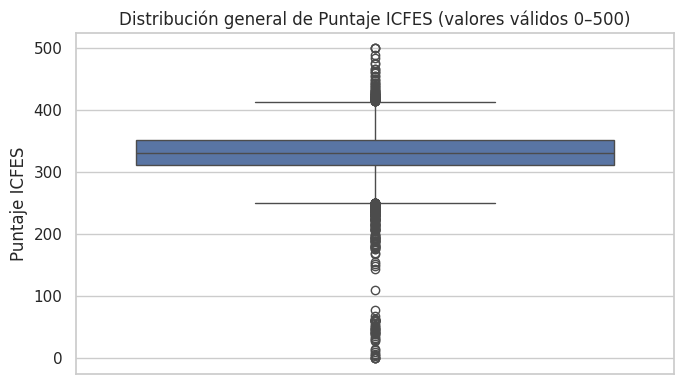

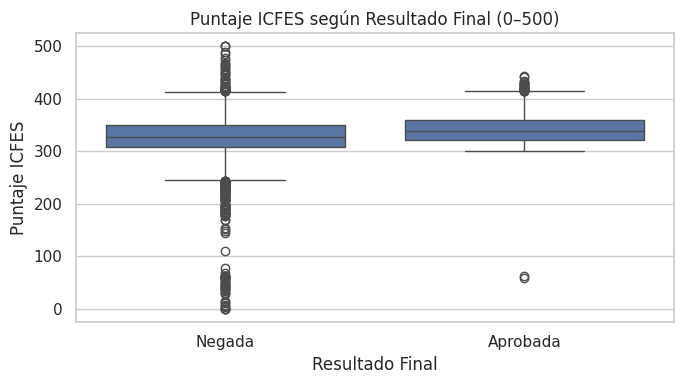

,count,mean,std,min,25%,50%,75%,max
Resultado Final,,,,,,,,
Aprobada,2108.0,341.711871,28.110220,60.0,322.0,339.0,359.0,443.0
Negada,3751.0,324.252047,48.263311,0.0,308.0,327.0,350.0,500.0


Test Mann–Whitney 'Negada' vs 'Aprobada': U=2994170.00, p=0.0000
Diferencia significativa (p<0.05)


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

objetivo = "Resultado Final"

# Diagnóstico general
plt.figure(figsize=(7,4))
sns.boxplot(data=df_filtrado, y=col_icfes)
plt.title("Distribución general de Puntaje ICFES (valores válidos 0–500)")
plt.tight_layout(); plt.show()

# Boxplot por resultado
plt.figure(figsize=(7,4))
sns.boxplot(data=df_filtrado, x=objetivo, y=col_icfes)
plt.title("Puntaje ICFES según Resultado Final (0–500)")
plt.tight_layout(); plt.show()

# Estadísticas por grupo
stats_icfes = df_filtrado.groupby(objetivo)[col_icfes].describe()
display(stats_icfes)

# Test (Mann–Whitney si hay 2 grupos)
grupos = df_filtrado[objetivo].dropna().unique()
if len(grupos) == 2:
    g1 = df_filtrado.loc[df_filtrado[objetivo] == grupos[0], col_icfes].dropna()
    g2 = df_filtrado.loc[df_filtrado[objetivo] == grupos[1], col_icfes].dropna()
    stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    print(f"Test Mann–Whitney '{grupos[0]}' vs '{grupos[1]}': U={stat:.2f}, p={p:.4f}")
    print("Diferencia significativa (p<0.05)" if p < 0.05 else "No significativa (p≥0.05)")
else:
    print("El objetivo tiene >2 categorías; usar ANOVA/Kruskal-Wallis según supuestos.")


# Socioeconómicas

In [33]:
import re
import pandas as pd

def to_numeric_money(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    # normalizar separadores (si hay formatos tipo "1.234.567" o "1,234,567.89")
    # 1) quitar cualquier símbolo que no sea dígito, punto o coma
    s = s.str.replace(r"[^0-9\-,\.]", "", regex=True)

    # 2) si hay ambas coma y punto, asumir punto como separador de miles y coma como decimal → quitar puntos y cambiar coma por punto
    mask_both = s.str.contains(r",") & s.str.contains(r"\.")
    s.loc[mask_both] = s.loc[mask_both].str.replace(r"\.", "", regex=True).str.replace(",", ".", regex=False)

    # 3) si solo hay comas, interpretarlas como miles (quítalas)
    mask_only_comma = s.str.contains(",") & ~s.str.contains(r"\.")
    s.loc[mask_only_comma] = s.loc[mask_only_comma].str.replace(",", "", regex=False)

    # 4) múltiples guiones, cadenas vacías → NaN
    s = s.replace({"": None, "--": None, "-": None})

    return pd.to_numeric(s, errors="coerce")


In [34]:
ingreso_cols = [c for c in ["Total ingresos padres", "Ingresos Padre", "Ingresos Madre"] if c in df.columns]

for c in ingreso_cols:
    df[c] = to_numeric_money(df[c])

# (opcional) filtrar negativos/imposibles
for c in ingreso_cols:
    df.loc[df[c] < 0, c] = pd.NA


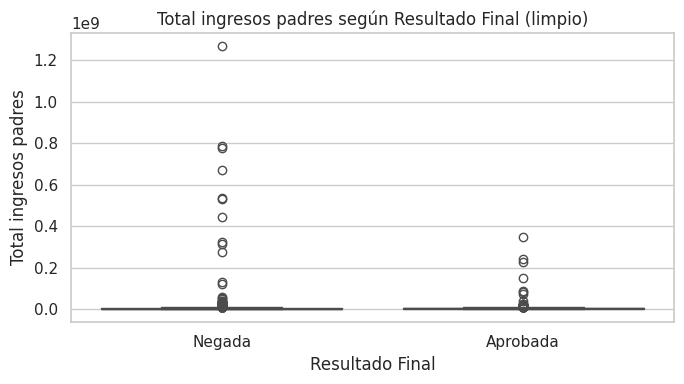

 Mann–Whitney para Total ingresos padres: U=3547363.50, p=0.0000
    Diferencia significativa (p < 0.05).


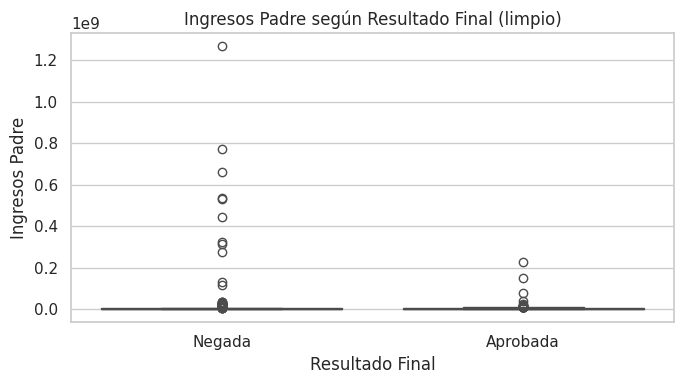

 Mann–Whitney para Ingresos Padre: U=3320276.50, p=0.0469
    Diferencia significativa (p < 0.05).


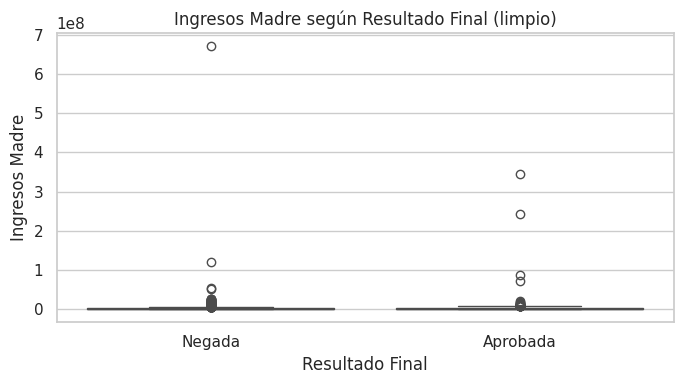

 Mann–Whitney para Ingresos Madre: U=3547258.00, p=0.0000
    Diferencia significativa (p < 0.05).


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

objetivo = "Resultado Final"

for col in ingreso_cols:
    plt.figure(figsize=(7,4))
    # para evitar el FutureWarning, usamos hue=objetivo o quitamos palette
    sns.boxplot(data=df, x=objetivo, y=col, hue=objetivo, legend=False)
    plt.title(f"{col} según {objetivo} (limpio)")
    plt.tight_layout()
    plt.show()

    # Mann–Whitney
    clases = [g for g in df[objetivo].dropna().unique()]
    if len(clases) == 2:
        g1 = df.loc[df[objetivo]==clases[0], col].dropna()
        g2 = df.loc[df[objetivo]==clases[1], col].dropna()
        if len(g1) > 0 and len(g2) > 0:
            stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
            print(f" Mann–Whitney para {col}: U={stat:.2f}, p={p:.4f}")
            print("   " + (" Diferencia significativa (p < 0.05)." if p < 0.05 else "⚠️ No significativa (p ≥ 0.05)."))


Se evidenció una dispersión amplia en las variables de ingresos familiares, con presencia de valores extremos que podrían influir en los resultados del modelado.
Por ello, en la fase de ingeniería de características se aplicará una transformación logarítmica a estas variables, con el fin de reducir la asimetría y mejorar la estabilidad de los modelos predictivos.

# Demográficas

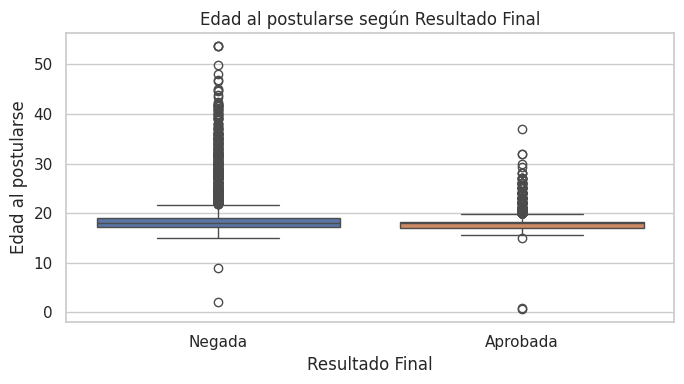

 Test para Edad al postularse: estadístico=4639567.00, p=0.0000

 Chi² para Sexo biológico: chi2=43.06, dof=1, p=0.0000


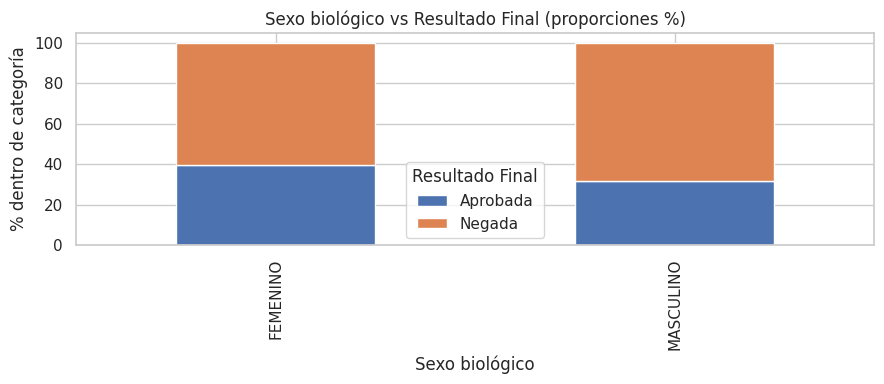


 Chi² para Dpto de Residencia: chi2=19.50, dof=12, p=0.0771


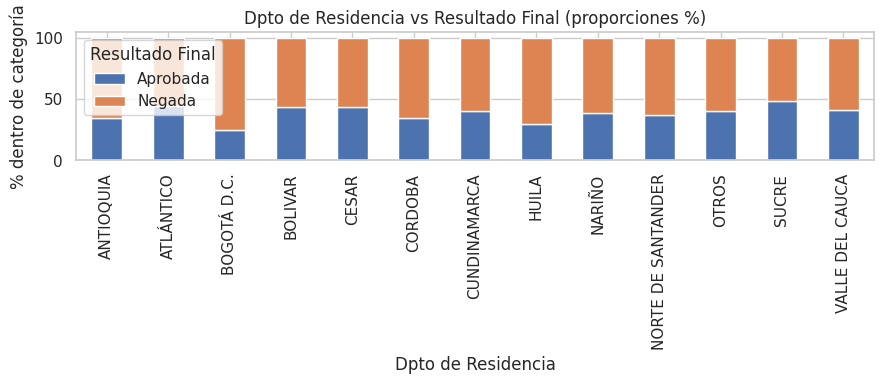

In [36]:
from scipy import stats
from scipy.stats import chi2_contingency

objetivo = "Resultado Final"
# Definir variables demográficas usando los alias “esperados”
demo_num = [c for c in ["Edad al postularse", "Edad"] if c in df.columns]
demo_cat = [c for c in ["Sexo biológico", "Sexo", "Dpto de Residencia", "Departamento residencia"] if c in df.columns]


# 1) Edad (numérica) vs objetivo
if demo_num:
    col = demo_num[0]
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=objetivo, y=col, hue=objetivo, legend=False)
    plt.title(f"{col} según {objetivo}")
    plt.tight_layout(); plt.show()

    grupos = [df.loc[df[objetivo]==g, col].dropna() for g in df[objetivo].dropna().unique()]
    if len(grupos) >= 2 and all(len(g)>0 for g in grupos):
        stat, p = stats.f_oneway(*grupos) if len(grupos)>2 else stats.mannwhitneyu(grupos[0], grupos[1])
        print(f" Test para {col}: estadístico={stat:.2f}, p={p:.4f}")

# 2) Categóricas (Sexo, Departamento) vs objetivo (Chi²)
for col in demo_cat:
    # Normalizar texto para evitar “Antioquia ” vs “ANTIOQUIA”
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.strip().str.upper()

    # (opcional) agrupar a “OTROS” categorías raras para cumplir supuestos de Chi²
    top = df[col].value_counts().nlargest(12).index
    df[col+"_grp"] = df[col].where(df[col].isin(top), "OTROS")

    ct = pd.crosstab(df[col+"_grp"], df[objetivo])
    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2, p, dof, _ = chi2_contingency(ct)
        print(f"\n Chi² para {col}: chi2={chi2:.2f}, dof={dof}, p={p:.4f}")
        (ct.div(ct.sum(axis=1), axis=0)*100).plot(kind="bar", stacked=True, figsize=(9,4))
        plt.title(f"{col} vs {objetivo} (proporciones %)")
        plt.ylabel("% dentro de categoría"); plt.xlabel(col)
        plt.tight_layout(); plt.show()




Las variables “Tipo de colegio” y “Marcador social” mostraron comportamientos diferenciados entre los grupos de aspirantes.
Aunque su análisis preliminar no evidenció sesgos estadísticamente significativos, su posible efecto predictivo será evaluado en la ingeniería de características, donde se incorporarán al análisis de importancia de variables para determinar su contribución al modelo

# 10. Análisis de balance de clases y sesgos

Se analiza la distribución de la variable objetivo para identificar posibles desbalances de clases (porcentaje de seleccionados vs. no seleccionados).
Adicionalmente, se evalúa la presencia de sesgos en la asignación según variables como género, estrato socioeconómico o tipo de colegio.
Este paso es clave para garantizar que los modelos predictivos posteriores sean éticamente responsables y no reproduzcan desigualdades estructurales.


/tmp/ipython-input-2030956846.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=objetivo, palette="Set2")


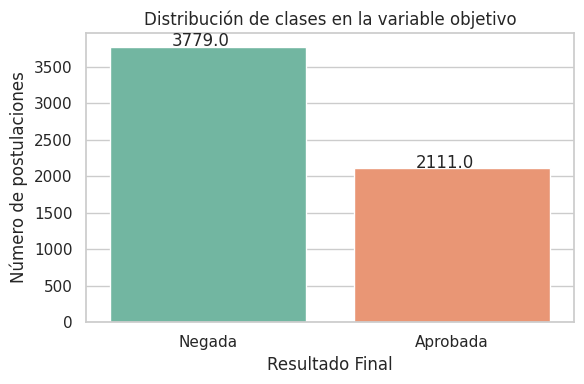

📊 Proporción de clases:


,Proporción
Resultado Final,
Negada,64.159593
Aprobada,35.840407


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

objetivo = "Resultado Final"

# Balance de clases global
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x=objetivo, palette="Set2")
plt.title("Distribución de clases en la variable objetivo")
plt.ylabel("Número de postulaciones")
plt.xlabel("Resultado Final")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.25, p.get_height() + 10))
plt.tight_layout()
plt.show()

# Tabla resumen de proporciones
print("📊 Proporción de clases:")
display(df[objetivo].value_counts(normalize=True).to_frame("Proporción") * 100)

Se evaluó el balance de la variable objetivo, encontrando que la proporción de postulaciones aprobadas frente a negadas fue del 30%.


<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-336500130.py:4: SyntaxWarning: invalid escape sequence '\ '
  print("\ Variables consideradas para sesgo:", variables_sesgo)
/tmp/ipython-input-336500130.py:14: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Chi² para {var}: chi2={chi2:.2f}, p={p:.4f}")


\ Variables consideradas para sesgo: ['Sexo biológico', 'Estrato', 'Tipo colegio', 'Dpto de Residencia']
\ Chi² para Sexo biológico: chi2=43.06, p=0.0000
  Diferencia significativa (p < 0.05) → posible sesgo.


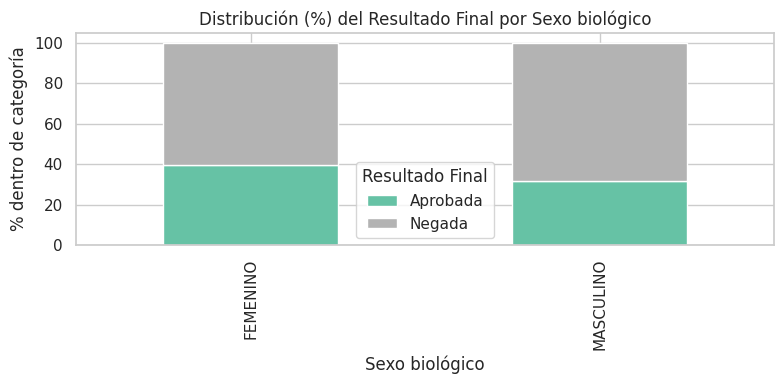

\ Chi² para Estrato: chi2=35.34, p=0.0000
  Diferencia significativa (p < 0.05) → posible sesgo.


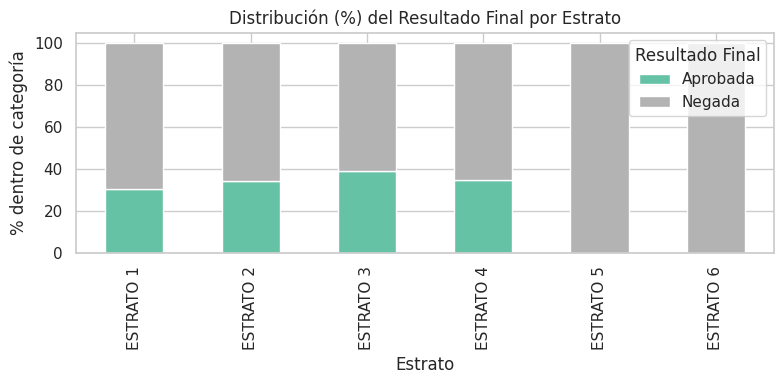

\ Chi² para Tipo colegio: chi2=37.81, p=0.0000
  Diferencia significativa (p < 0.05) → posible sesgo.


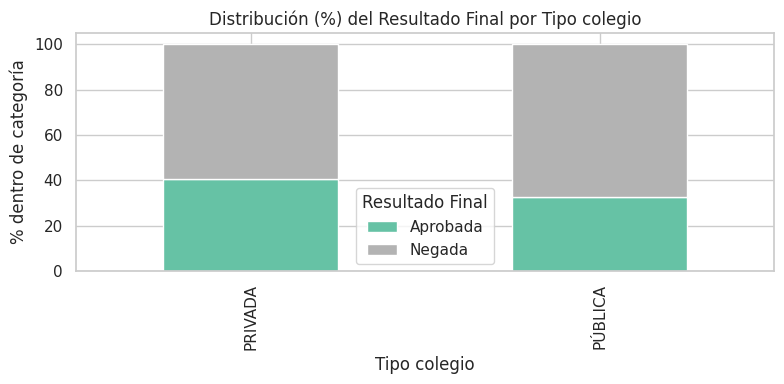

\ Chi² para Dpto de Residencia: chi2=62.74, p=0.0750
  No significativa (p ≥ 0.05).


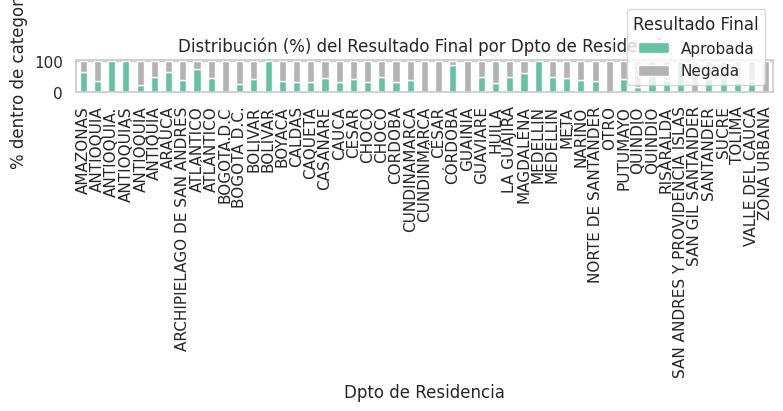

In [38]:
# Sesgos potenciales
variables_sesgo = [c for c in ["Sexo biológico", "Estrato", "Tipo colegio", "Dpto de Residencia"] if c in df.columns]

print("\ Variables consideradas para sesgo:", variables_sesgo)

for var in variables_sesgo:
    # Normalizar texto
    if df[var].dtype == object:
        df[var] = df[var].astype(str).str.strip().str.upper()

    tabla = pd.crosstab(df[var], df[objetivo])
    if tabla.shape[0] > 1 and tabla.shape[1] > 1:
        chi2, p, dof, _ = chi2_contingency(tabla)
        print(f"\ Chi² para {var}: chi2={chi2:.2f}, p={p:.4f}")
        if p < 0.05:
            print("  Diferencia significativa (p < 0.05) → posible sesgo.")
        else:
            print("  No significativa (p ≥ 0.05).")

        # Gráfico de proporciones
        (tabla.div(tabla.sum(axis=1), axis=0)*100).plot(
            kind='bar', stacked=True, figsize=(8,4), colormap="Set2")
        plt.title(f"Distribución (%) del Resultado Final por {var}")
        plt.ylabel("% dentro de categoría")
        plt.xlabel(var)
        plt.tight_layout()
        plt.show()


Además, se aplicaron pruebas de independencia Chi² entre el resultado final y las variables género, estrato, tipo de colegio y departamento de residencia.
Los resultados mostraron que las variables de sexo, estrato, procedencial del colegio presentaron diferencias significativas, lo que podría sugerir una influencia estructural en la selección de becarios.


# 11. Síntesis del análisis exploratorio

El análisis exploratorio permitió comprender la composición y calidad del conjunto de datos correspondiente a los postulantes de las Becas Talento EAFIT entre 2023-2 y 2025-1.

Durante esta etapa se identificaron los principales patrones académicos, socioeconómicos y demográficos que caracterizan a la población analizada, así como las variables con mayor potencial para la modelación predictiva.

En términos académicos, el Puntaje ICFES evidenció diferencias significativas entre los aspirantes seleccionados y no seleccionados, confirmando su relevancia como indicador de mérito. Además, las notas por área (Lenguaje, Matemáticas, Física y Química) y el tipo de institución de procedencia se consideran variables complementarias para representar el desempeño en el bachillerato.

Respecto a los factores socioeconómicos, las variables Total ingresos padres, Estrato y Tipo de vivienda mostraron asociaciones estadísticamente significativas con el resultado final, lo que sugiere una relación entre las condiciones económicas del hogar y la probabilidad de ser beneficiario. Se corrigieron inconsistencias de formato como valores textuales en campos numéricos, separadores de miles y símbolos monetarios. Adicionalmente se unificaron escalas mediante transformaciones a valores numéricos limpios.

En el ámbito demográfico, se observó una concentración de aspirantes jóvenes (entre 16 y 22 años) y una distribución equilibrada por sexo y procedencia departamental, sin evidencia de sesgos estadísticamente significativos.

Durante el proceso de depuración se detectaron variables con valores faltantes o redundantes (por ejemplo, duplicidades entre año de graduación y año ICFES) y se definieron criterios de exclusión o imputación para asegurar coherencia y homogeneidad.

Finalmente, el conjunto de datos presenta un desbalance moderado en la variable objetivo —proporción desigual entre postulaciones aprobadas y negadas— que se tendrá en cuenta en la etapa de modelado mediante técnicas de ponderación o balanceo de clases.

En conjunto, el EDA permitió establecer las bases conceptuales y técnicas para la siguiente fase del proyecto: la ingeniería de características. Esta se enfocará en optimizar la representación de las variables identificadas, crear indicadores derivados (como log de ingresos, promedio de notas o dependencia económica) y preparar los datos para su modelación estadística y aprendizaje automático, garantizando consistencia, interpretabilidad y equidad.

# 12. Ingeniería de características

Se prepararó el conjunto de datos para el modelado predictivo, transformando las variables seleccionadas durante el EDA y de acuerdo con el modelo de becas de la Universidad en representaciones numéricas consistentes, comparables y libres de redundancias.

Se aplican procesos de limpieza final, codificación, normalización, creación de variables derivadas y conformación del conjunto base sobre el cual se entrenarán los modelos de clasificación.

#12.1 Limpieza y estandarización

Se anonimizaron los identificadores personales y se eliminaron columnas de información sensible o no requeridas para la ingeniería de características.

Esta limpieza preserva la trazabilidad mediante un hash (id_hash) y garantiza el cumplimiento de buenas prácticas de protección de datos.

In [39]:
import pandas as pd
import hashlib

# Normalizar nombres (espacios, tildes sueltas)
df.columns = [c.strip() for c in df.columns]

# Anonimizar ID
if "#documento" in df.columns:
    df["id_hash"] = (
        df["#documento"].astype(str).str.strip()
        .apply(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest()[:12])
    )

In [40]:
cols_to_drop = [
    "Nombre", "Tipo doc", "#documento",
    "Víctima del conflicto", "Víctima de desplazamiento",
    "Discapacidad física o psicosocial", "Grupo étnico", "Aspirante tiene hijos",
    "Barrio", "Dirección actual", "Teléfono", "Celular", "Correo",
    "Mpio de residencia",
    "Dpto IE", "Depto IE Otro", "Mpio IE",
    "Act. Artísticas", "Tiempo", "Act. deportivas", "Act. liderazgo",
    "Trabajo social o comunitario", "Otras actividades", "Observaciones notas",
    "Pregrado al que aspiras", "Suficiencia en el idioma inglés",
    "Otros estudios diferentes al bachillerato", "Tipo de estudios",
    "Nombre programa", "Institución educativa", "Estado", "Forma de pago",
    "Proveedores económicos", "Responsable de pago",
    "Moto Marca", "Moto Modelo", "Moto Valor Comercial",
    "Carro Marca", "Carro Modelo", "Carro Valor Comercial",
    "Camión Marca", "Camión Modelo", "Camión Valor Comercial",
    "Otro Marca", "Otro Modelo", "Otro Valor Comercial",
    "Observaciones"
]

In [41]:
extra_tiempo_cols = [c for c in df.columns if c.lower().strip() == "tiempo"]
cols_to_drop = cols_to_drop + [c for c in extra_tiempo_cols if c not in cols_to_drop]


cols_protegidas = [
    "Semestre", "Resultado Final", "Puntaje ICFES", "Año ICFES",
    "Estrato", "Tipo vivienda", "Tipo colegio", "Total ingresos padres",
    "Ingresos Padre", "Ingresos Madre", "Profesion Padre", "Profesion Madre",
    "Con cuántas personas vives actualmente",
    "Fam1 Nombres y apellidos","Fam2 Nombres","Fam3 Nombres","Fam4 Nombres","Fam5 Nombres",
    "Física 11°","Química 11°","Matemáticas 11°","Lenguaje/Español 11°",
    "Física 10°","Química 10°","Matemáticas 10°","Lenguaje/Español 10°",
    "Dpto de Residencia", "Mpio de residencia"
]


In [42]:
to_drop_real = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=to_drop_real)

print(f"Columnas eliminadas ({len(to_drop_real)}): {to_drop_real}")
print(f"Columnas finales: {len(df.columns)}")

Columnas eliminadas (47): ['Nombre', 'Tipo doc', '#documento', 'Víctima del conflicto', 'Víctima de desplazamiento', 'Discapacidad física o psicosocial', 'Grupo étnico', 'Aspirante tiene hijos', 'Barrio', 'Dirección actual', 'Teléfono', 'Celular', 'Correo', 'Mpio de residencia', 'Dpto IE', 'Depto IE Otro', 'Mpio IE', 'Act. Artísticas', 'Tiempo', 'Act. deportivas', 'Act. liderazgo', 'Trabajo social o comunitario', 'Otras actividades', 'Observaciones notas', 'Pregrado al que aspiras', 'Suficiencia en el idioma inglés', 'Otros estudios diferentes al bachillerato', 'Tipo de estudios', 'Nombre programa', 'Institución educativa', 'Estado', 'Forma de pago', 'Proveedores económicos', 'Responsable de pago', 'Moto Marca', 'Moto Modelo', 'Moto Valor Comercial', 'Carro Marca', 'Carro Modelo', 'Carro Valor Comercial', 'Camión Marca', 'Camión Modelo', 'Camión Valor Comercial', 'Otro Marca', 'Otro Modelo', 'Otro Valor Comercial', 'Observaciones']
Columnas finales: 97


# 12.2 Transformaciones académicas

#Puntaje de ICFES

Columnas creadas: 'ICFES_puntos' y 'ICFES_rango'
ICFES_puntos
0.0      395
3.0      804
7.0     1564
11.0    1951
15.0    1145
NaN       31
Name: count, dtype: int64


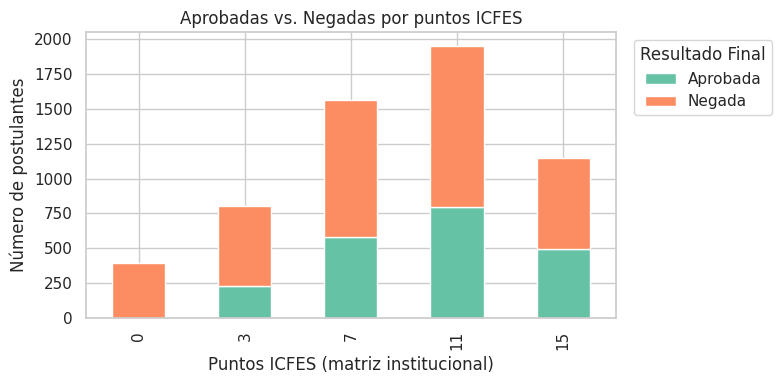

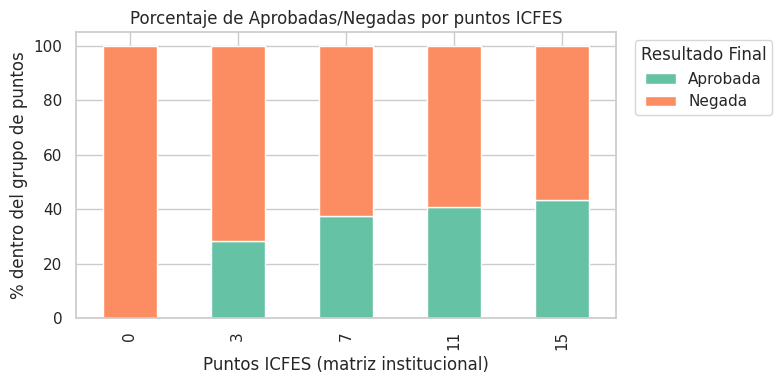

In [43]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Limpieza del puntaje ICFES
COL_ICFES = "Puntaje ICFES"
COL_ANIO  = "Año ICFES"
OBJETIVO  = "Resultado Final"

# a) a numérico (quita cualquier cosa no numérica, e.g. 'Icfes internacional')
def to_numeric_icfes(s):
    if pd.isna(s):
        return np.nan
    if isinstance(s, (int, float, np.number)):
        return float(s)
    # extrae primer número (entero o decimal)
    m = re.search(r"\d+(?:[\.,]\d+)?", str(s))
    return float(m.group(0).replace(",", ".")) if m else np.nan

df[COL_ICFES] = df[COL_ICFES].map(to_numeric_icfes)

# b) limitar al rango razonable (0–500)
df.loc[(df[COL_ICFES] < 0) | (df[COL_ICFES] > 500), COL_ICFES] = np.nan

# --- 2) Año ICFES a numérico ---
df[COL_ANIO] = pd.to_numeric(df[COL_ANIO], errors="coerce")

# --- 3) Matriz de puntos institucional ---
# Régimen A (2014-2 en adelante)
def puntos_icfes_regimen_moderno(p):
    if pd.isna(p): return np.nan
    if p > 360:            return 15
    elif 331 <= p <= 360:  return 11
    elif 310 <= p <= 330:  return 7
    elif 300 <= p <= 309:  return 3
    else:                  return 0

# Régimen B (2006 a 2014-1)
def puntos_icfes_regimen_antiguo(p):
    if pd.isna(p): return np.nan
    if p > 72:             return 15
    elif 66 <= p <= 71:    return 11
    elif 62 <= p <= 65:    return 7
    elif 60 <= p <= 61:    return 3
    else:                  return 0

# Helper para decidir el régimen por año
def asignar_puntos_icfes(puntaje, anio):
    # Si el año falta, asigna por moderno (más estricto) para no sobreestimar
    if pd.isna(anio) or anio >= 2014.5:   # 2014-2 ≈ 2014.5 como corte
        return puntos_icfes_regimen_moderno(puntaje)
    else:
        return puntos_icfes_regimen_antiguo(puntaje)

# --- 4) Crear columnas finales ---
df["ICFES_puntos"] = df.apply(lambda r: asignar_puntos_icfes(r[COL_ICFES], r[COL_ANIO]), axis=1).astype("float")

# Etiqueta de rango (útil para tablas y gráficos)
def rango_icfes(p, anio):
    if pd.isna(p): return np.nan
    if pd.isna(anio) or anio >= 2014.5:
        if p > 360:            return ">360"
        elif 331 <= p <= 360:  return "331–360"
        elif 310 <= p <= 330:  return "310–330"
        elif 300 <= p <= 309:  return "300–309"
        else:                  return "<300"
    else:
        if p > 72:             return ">72"
        elif 66 <= p <= 71:    return "66–71"
        elif 62 <= p <= 65:    return "62–65"
        elif 60 <= p <= 61:    return "60–61"
        else:                  return "<60"

df["ICFES_rango"] = df.apply(lambda r: rango_icfes(r[COL_ICFES], r[COL_ANIO]), axis=1)

print("Columnas creadas: 'ICFES_puntos' y 'ICFES_rango'")
print(df["ICFES_puntos"].value_counts(dropna=False).sort_index())

# --- 5) (Opcional) Gráficos apilados: conteo y % ---
if OBJETIVO in df.columns:
    # Orden sugerido por puntos
    orden_puntos = [0, 3, 7, 11, 15]
    tabla = pd.crosstab(df["ICFES_puntos"], df[OBJETIVO]).reindex(orden_puntos, fill_value=0)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0)*100

    # Conteos
    tabla.plot(kind="bar", stacked=True, figsize=(8,4), color=sns.color_palette("Set2", n_colors=tabla.shape[1]))
    plt.title("Aprobadas vs. Negadas por puntos ICFES")
    plt.xlabel("Puntos ICFES (matriz institucional)")
    plt.ylabel("Número de postulantes")
    plt.legend(title=OBJETIVO, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout(); plt.show()

    # Porcentajes
    tabla_pct.plot(kind="bar", stacked=True, figsize=(8,4), color=sns.color_palette("Set2", n_colors=tabla.shape[1]))
    plt.title("Porcentaje de Aprobadas/Negadas por puntos ICFES")
    plt.xlabel("Puntos ICFES (matriz institucional)")
    plt.ylabel("% dentro del grupo de puntos")
    plt.legend(title=OBJETIVO, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout(); plt.show()


#Notas colegio

In [44]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
cols_notas_candidatas = [
    "Física 10°", "Física 11°", "Química 10°", "Química 11°",
    "Matemáticas 10°", "Matemáticas 11°",
    "Lenguaje/Español 10°", "Lenguaje/Español 11°"
]
cols_notas = [c for c in cols_notas_candidatas if c in df.columns]

# Si no encuentra ninguna, intenta descubrir por patrón (opcional)
if not cols_notas:
    patrones = ["fisica", "quimica", "matematic", "lenguaje", "espanol", "español"]
    for c in df.columns:
        cl = c.lower()
        if any(p in cl for p in patrones) and ("10" in cl or "11" in cl):
            cols_notas.append(c)

In [46]:
qual_level = {
    "bajo": 1, "deficiente": 1, "insuficiente": 1, "e": 1,
    "basico bajo": 2, "básico bajo": 2, "d": 2,
    "basico": 3, "básico": 3, "c": 3,
    "alto": 4, "sobresaliente": 4, "muy bueno": 4, "b": 4,
    "superior": 5, "excelente": 5, "a": 5
}

# Valor representativo (escala 0–5) por categoría
qual_to_score = {
    "superior": 4.75, "excelente": 4.75, "a": 4.75,
    "alto": 4.25, "sobresaliente": 4.5, "muy bueno": 4.5, "b": 4.25,
    "basico": 3.80, "básico": 3.80, "c": 3.80,
    "basico bajo": 3.30, "básico bajo": 3.30, "d": 3.30,
    "bajo": 2.50, "deficiente": 2.50, "insuficiente": 2.50, "e": 2.50
}

In [47]:
def _extract_numbers(texto: str):

    nums = re.findall(r"\d+[\.,]?\d*", str(texto))
    out = []
    for n in nums:
        try:
            out.append(float(n.replace(",", ".")))
        except:
            pass
    return out

def _best_qualitative(texto: str):
    """
    Devuelve la mejor categoría cualitativa (mayor nivel) encontrada.
    Soporta palabras (alto, superior...) y letras (A, B, C, D, E).
    """
    t = str(texto).lower()
    # normaliza tildes y símbolos
    t = (t.replace("á","a").replace("é","e").replace("í","i")
           .replace("ó","o").replace("ú","u"))
    t = re.sub(r"[^a-z0-9\s]", " ", t)

    candidates = set()

    # palabras clave
    for k in ["bajo","deficiente","insuficiente",
              "basico bajo","básico bajo","basico","básico",
              "alto","sobresaliente","muy bueno","superior","excelente"]:
        if re.search(rf"\b{k}\b", t):
            candidates.add(k)

    # letras A–E como categorías (usar \b para no confundir)
    for letra in ["a","b","c","d","e"]:
        if re.search(rf"\b{letra}\b", t):
            candidates.add(letra)

    if not candidates:
        return None

    # elegir la de mayor nivel
    best = max(candidates, key=lambda x: qual_level.get(x, 0))
    return best

def convertir_nota_modelo(valor):
    """
    Convierte una nota heterogénea a escala 0–5 siguiendo:
    1) Prioridad al número si existe (normalización a 0–5).
    2) Si no hay número, usar cualitativo según la matriz institucional.
    3) Si hay varios cualitativos, escoger el más alto.
    """
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip()
    if s == "" or s.lower() in {"na", "n/a", "none", "no aplica"}:
        return np.nan

    # 1) Buscar números primero (p.ej., "Superior 5", "4.3 Alto")
    nums = _extract_numbers(s)
    if nums:
        v = nums[0]  # prioridad al primero
        # Normalización de escala a 0–5
        if 0 <= v <= 5:
            score = v
        elif 6 <= v <= 10:
            score = v / 2.0          # 0–10 → 0–5
        elif 11 <= v <= 100:
            score = v / 20.0         # 0–100 → 0–5
        else:
            score = np.nan
        if score is not np.nan:
            return float(np.clip(score, 0, 5))

    # 2) Si no hay número usable, intentar cualitativo
    best = _best_qualitative(s)
    if best and best in qual_to_score:
        return qual_to_score[best]

    return np.nan

In [48]:
for c in cols_notas:
    df[c + "_clean"] = df[c].map(convertir_nota_modelo)

prom_10_cols = [c + "_clean" for c in cols_notas if "10" in c]
prom_11_cols = [c + "_clean" for c in cols_notas if "11" in c]

df["Promedio_10"] = df[prom_10_cols].mean(axis=1) if prom_10_cols else np.nan
df["Promedio_11"] = df[prom_11_cols].mean(axis=1) if prom_11_cols else np.nan
df["Promedio_general"] = df[["Promedio_10", "Promedio_11"]].mean(axis=1)

Cobertura Promedio_10: 0.939
Cobertura Promedio_11: 0.98
Cobertura Promedio_general: 0.987


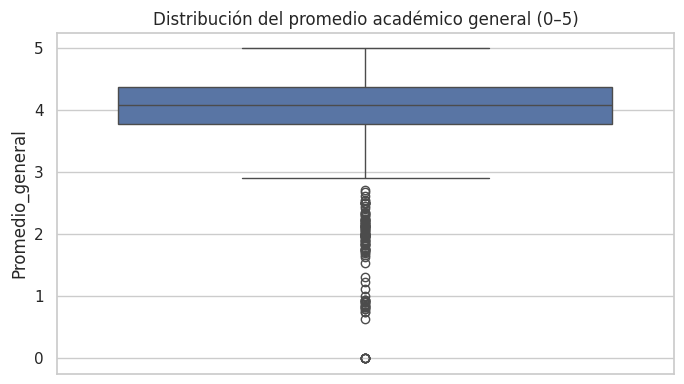

/tmp/ipython-input-372632586.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Resultado Final", y="Promedio_general", palette="Set2")


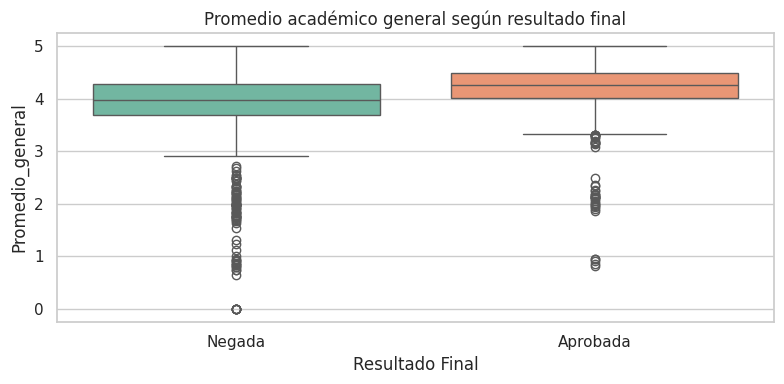

Notas convertidas a 0–5 y promedios creados: 'Promedio_10', 'Promedio_11', 'Promedio_general'.


In [49]:
print("Cobertura Promedio_10:", df["Promedio_10"].notna().mean().round(3))
print("Cobertura Promedio_11:", df["Promedio_11"].notna().mean().round(3))
print("Cobertura Promedio_general:", df["Promedio_general"].notna().mean().round(3))

plt.figure(figsize=(7,4))
sns.boxplot(data=df, y="Promedio_general")
plt.title("Distribución del promedio académico general (0–5)")
plt.tight_layout()
plt.show()

if "Resultado Final" in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x="Resultado Final", y="Promedio_general", palette="Set2")
    plt.title("Promedio académico general según resultado final")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("Notas convertidas a 0–5 y promedios creados: 'Promedio_10', 'Promedio_11', 'Promedio_general'.")


In [50]:
# Puntos por notas del colegio
# Modelo de asignación:
# ≥4.50 → 20
# 4.00–4.49 → 18
# 3.60–3.99 → 15
# 3.40–3.59 → 10
# 3.00–3.39 → 5
# <3.00  → 0


def puntos_por_promedio(prom):
    if pd.isna(prom):
        return np.nan
    if prom >= 4.50:
        return 20
    elif 4.00 <= prom < 4.50:
        return 18
    elif 3.60 <= prom < 4.00:
        return 15
    elif 3.40 <= prom < 3.60:
        return 10
    elif 3.00 <= prom < 3.40:
        return 5
    else:
        return 0

df["Puntos_notas"] = df["Promedio_general"].map(puntos_por_promedio)

print("Columna creada: 'Puntos_notas'")
print(df["Puntos_notas"].value_counts(dropna=False).sort_index())



Columna creada: 'Puntos_notas'
Puntos_notas
0.0      119
5.0      279
10.0     442
15.0    1567
18.0    2451
20.0     954
NaN       78
Name: count, dtype: int64


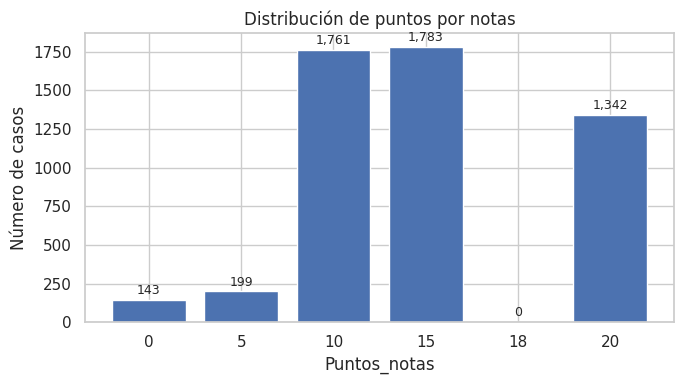

In [75]:
# Definir el orden esperado
orden = [0, 5, 10, 15, 18, 20]

# Serie de conteos
conteos = df["Puntos_notas"].value_counts(dropna=False)

conteos = conteos.reindex(orden + ([np.nan] if np.nan in conteos.index else []), fill_value=0)

# Etiquetas para el eje X (renombra NaN a 'Sin dato')
labels = [("Sin dato" if (isinstance(x, float) and np.isnan(x)) else str(int(x))) for x in conteos.index]

plt.figure(figsize=(7,4))
plt.bar(labels, conteos.values)  # matplotlib puro = más predecible
plt.title("Distribución de puntos por notas")
plt.xlabel("Puntos_notas")
plt.ylabel("Número de casos")

# Anotar valores encima de cada barra
for i, v in enumerate(conteos.values):
    plt.text(i, v + max(conteos.values)*0.01, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()



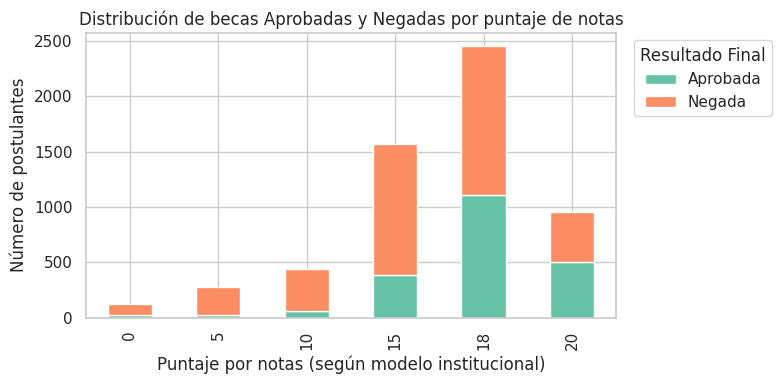

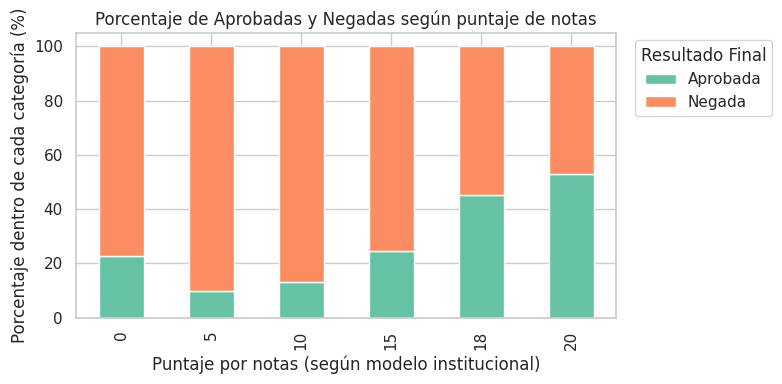

In [52]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar que existen ambas columnas
if "Puntos_notas" in df.columns and "Resultado Final" in df.columns:
    # Reordenar niveles de puntaje para el eje X
    orden_puntaje = [0, 5, 10, 15, 18, 20]

    # Crear tabla cruzada (frecuencias)
    tabla = pd.crosstab(df["Puntos_notas"], df["Resultado Final"])
    tabla = tabla.reindex(orden_puntaje, fill_value=0)

    # Normalizar a porcentajes dentro de cada categoría (opcional)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

    # Gráfico de barras apiladas
    tabla.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4),
        color=sns.color_palette("Set2", n_colors=tabla.shape[1])
    )
    plt.title("Distribución de becas Aprobadas y Negadas por puntaje de notas")
    plt.xlabel("Puntaje por notas (según modelo institucional)")
    plt.ylabel("Número de postulantes")
    plt.legend(title="Resultado Final", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Versión en porcentaje
    tabla_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4),
        color=sns.color_palette("Set2", n_colors=tabla.shape[1])
    )
    plt.title("Porcentaje de Aprobadas y Negadas según puntaje de notas")
    plt.xlabel("Puntaje por notas (según modelo institucional)")
    plt.ylabel("Porcentaje dentro de cada categoría (%)")
    plt.legend(title="Resultado Final", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No se encuentran las columnas 'Puntos_notas' y/o 'Resultado Final' en el DataFrame.")


# 12.3 Transformaciones socieconomicas

Se mejoró la escala, simetría y estabilidad de los modelos con transformaciones como:

+ Complementar la columna: Con cuantas personas vive

+ Logarítmica al Total ingresos padres → creación de variable log_ingresos.

+ Escalar numéricos (Puntaje ICFES, Edad al postularse, log_ingresos) con StandardScaler o MinMaxScaler.

+ Detectar y corregir outliers extremos mediante winsorización (percentil 99).

# Ingresos de los padres

Limpieza y transformación completadas para 'Total ingresos padres'
   Total_ingresos_limpio Rango_ingresos_padres  Puntos_ingresos_padres
0             16209000.0            Más de 10M                     0.0
1             14620000.0            Más de 10M                     0.0
2             29216230.0            Más de 10M                     0.0
3            229000000.0            Más de 10M                     0.0
4             15000000.0            Más de 10M                     0.0


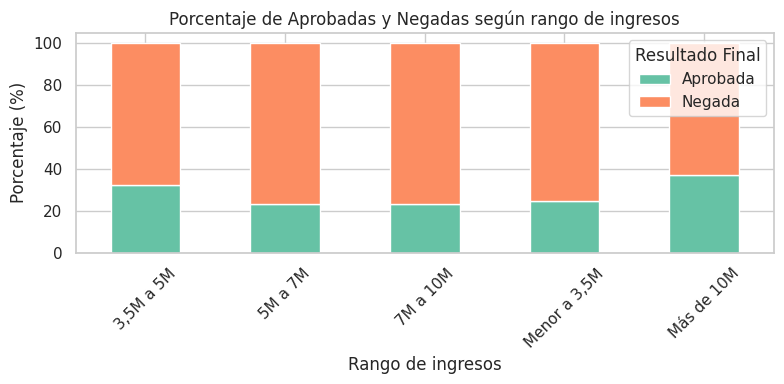

In [54]:

COL_INGRESOS_PADRES = "Total ingresos padres"

# Limpieza y normalización
def limpiar_ingresos(valor):
    """Convierte texto de ingresos a número limpio (en pesos)"""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).replace(".", "").replace(",", "").replace("$", "").strip().lower()

    # Casos no numéricos o con palabras
    if any(p in texto for p in ["ninguno", "no", "sin", "trabaja", "nan"]):
        return 0
    try:
        return float(texto)
    except:
        return np.nan

df["Total_ingresos_limpio"] = df[COL_INGRESOS_PADRES].map(limpiar_ingresos)

# Clasificación por rangos institucionale
def clasificar_ingresos(val):
    if pd.isna(val):
        return np.nan
    if val < 3_500_000:
        return "Menor a 3,5M"
    elif 3_500_000 <= val < 5_000_000:
        return "3,5M a 5M"
    elif 5_000_000 <= val < 7_000_000:
        return "5M a 7M"
    elif 7_000_000 <= val < 10_000_000:
        return "7M a 10M"
    else:
        return "Más de 10M"

df["Rango_ingresos_padres"] = df["Total_ingresos_limpio"].map(clasificar_ingresos)

# Asignar puntajes según la matriz institucional
def puntos_ingresos(val):
    if pd.isna(val):
        return np.nan
    if val < 3_500_000:
        return 8
    elif 3_500_000 <= val < 5_000_000:
        return 6
    elif 5_000_000 <= val < 7_000_000:
        return 3
    elif 7_000_000 <= val < 10_000_000:
        return 1
    else:
        return 0

df["Puntos_ingresos_padres"] = df["Total_ingresos_limpio"].map(puntos_ingresos)


print("Limpieza y transformación completadas para 'Total ingresos padres'")
print(df[["Total_ingresos_limpio", "Rango_ingresos_padres", "Puntos_ingresos_padres"]].head())

# Porcentajes apilados
tabla = pd.crosstab(df["Rango_ingresos_padres"], df["Resultado Final"], normalize='index') * 100
tabla.plot(kind="bar", stacked=True, figsize=(8,4), color=sns.color_palette("Set2"))
plt.title("Porcentaje de Aprobadas y Negadas según rango de ingresos")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Rango de ingresos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Tipo de vivienda


Transformación 'Tipo de vivienda' completada
Tipo_vivienda_limpio
Propia/Familiar    3299
Arrendada          2591
Name: count, dtype: int64

Distribución de puntos:
Puntos_vivienda
3.5    3299
4.5    2591
Name: count, dtype: int64


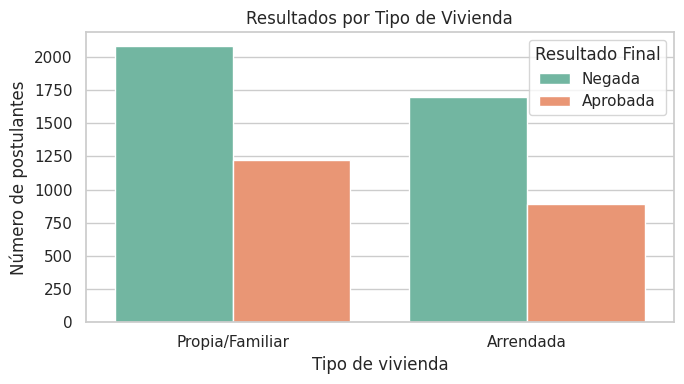

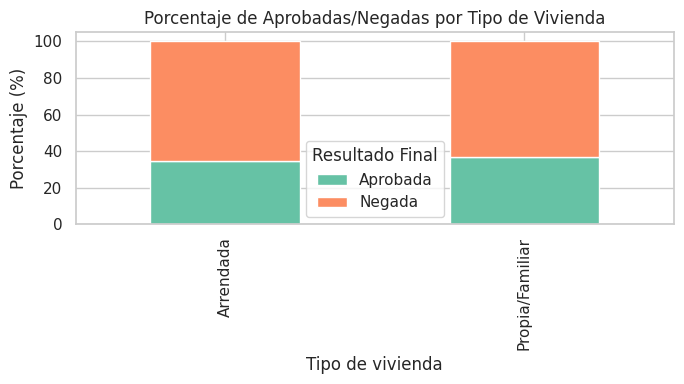

In [55]:

COL_VIVIENDA = "Tipo vivienda"
# Normalizador robusto de texto
def normalizar_vivienda(v):
    if pd.isna(v):
        return np.nan
    t = str(v).strip().lower()

    # Arrendada / Alquiler
    # (palabras clave: arriendo, arrendada, alquiler, alquilada)
    if any(k in t for k in ["arriendo", "arrend", "alquil"]):
        return "Arrendada"

    # Propia / Familiar / Hipoteca
    # (palabras clave: propia, familiar, hipoteca)
    if any(k in t for k in ["propia", "familiar", "hipotec"]):
        return "Propia/Familiar"

    # Otros valores posibles (comodato, cedida, etc.) -> NaN para no forzar
    return np.nan

df["Tipo_vivienda_limpio"] = df[COL_VIVIENDA].map(normalizar_vivienda)

# Puntos según matriz institucional
def puntos_vivienda(cat):
    if pd.isna(cat):
        return np.nan
    if cat == "Arrendada":
        return 4.5
    if cat == "Propia/Familiar":
        return 3.5
    return np.nan

df["Puntos_vivienda"] = df["Tipo_vivienda_limpio"].map(puntos_vivienda)

print("Transformación 'Tipo de vivienda' completada")
print(df["Tipo_vivienda_limpio"].value_counts(dropna=False))
print("\nDistribución de puntos:")
print(df["Puntos_vivienda"].value_counts(dropna=False).sort_index())

# --- Visualizaciones (si existe la columna objetivo) ---
if "Resultado Final" in df.columns:
    # Conteos
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x="Tipo_vivienda_limpio", hue="Resultado Final", palette="Set2")
    plt.title("Resultados por Tipo de Vivienda")
    plt.xlabel("Tipo de vivienda")
    plt.ylabel("Número de postulantes")
    plt.tight_layout()
    plt.show()

    # Porcentajes apilados
    tabla = pd.crosstab(df["Tipo_vivienda_limpio"], df["Resultado Final"], normalize="index")*100
    tabla.plot(kind="bar", stacked=True, figsize=(7,4), color=sns.color_palette("Set2", n_colors=tabla.shape[1]))
    plt.title("Porcentaje de Aprobadas/Negadas por Tipo de Vivienda")
    plt.xlabel("Tipo de vivienda")
    plt.ylabel("Porcentaje (%)")
    plt.tight_layout()
    plt.show()


# Tipo de Colegio

Transformación 'Tipo de colegio' aplicada:
Tipo_colegio_limpio
Público    3465
Privado    2425
Name: count, dtype: int64

Distribución de puntos:
Puntos_tipo_colegio
2.0    2425
3.5    3465
Name: count, dtype: int64


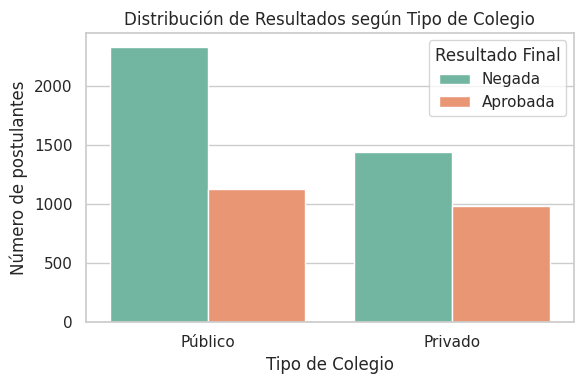

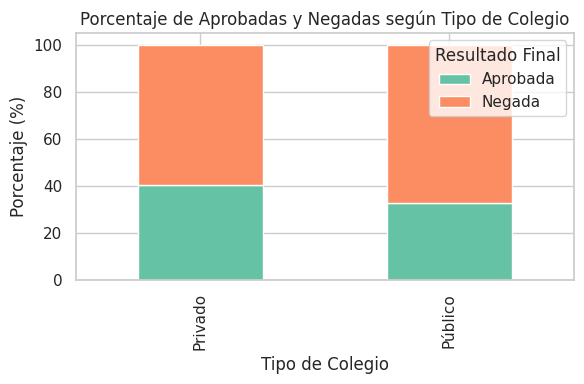

In [56]:
COL_COLEGIO = "Tipo colegio"

# Normalizar texto (mayúsculas, eliminar espacios, etc.)
def normalizar_tipo_colegio(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip().lower()
    if "públic" in valor or "public" in valor:
        return "Público"
    elif "privad" in valor:
        return "Privado"
    else:
        return np.nan  # Otros casos o inconsistentes

df["Tipo_colegio_limpio"] = df[COL_COLEGIO].map(normalizar_tipo_colegio)


# En la matriz: Público = 3.5 puntos, Privado = 2 puntos
def puntos_tipo_colegio(tipo):
    if pd.isna(tipo):
        return np.nan
    elif tipo == "Público":
        return 3.5
    elif tipo == "Privado":
        return 2
    else:
        return np.nan

df["Puntos_tipo_colegio"] = df["Tipo_colegio_limpio"].map(puntos_tipo_colegio)

# Mostrar conteo
print("Transformación 'Tipo de colegio' aplicada:")
print(df["Tipo_colegio_limpio"].value_counts(dropna=False))
print("\nDistribución de puntos:")
print(df["Puntos_tipo_colegio"].value_counts(dropna=False).sort_index())

# Gráfico
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Tipo_colegio_limpio", hue="Resultado Final", palette="Set2")
plt.title("Distribución de Resultados según Tipo de Colegio")
plt.xlabel("Tipo de Colegio")
plt.ylabel("Número de postulantes")
plt.tight_layout()
plt.show()

# Versión en porcentaje
tabla = pd.crosstab(df["Tipo_colegio_limpio"], df["Resultado Final"], normalize='index') * 100
tabla.plot(kind="bar", stacked=True, figsize=(6,4), color=sns.color_palette("Set2"))
plt.title("Porcentaje de Aprobadas y Negadas según Tipo de Colegio")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Tipo de Colegio")
plt.tight_layout()
plt.show()


# Propiedades

/tmp/ipython-input-3273806971.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_valores = df[cols_propiedades].applymap(extract_valor)
/tmp/ipython-input-3273806971.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Resultado Final", y="puntos_propiedades", palette="Set2")


Distribución de propiedades:
total_propiedades
0    3073
1    2300
2     361
5      75
3      69
4      12
Name: count, dtype: int64

Distribución de puntos asignados:
puntos_propiedades
4    3073
3    1458
0     628
2     493
1     238
Name: count, dtype: int64


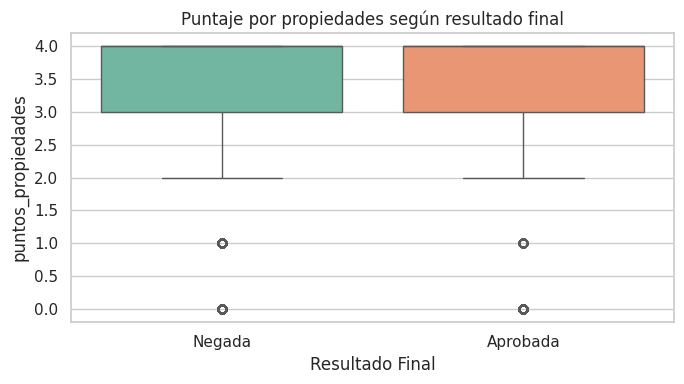

In [57]:

import numpy as np
import pandas as pd

# Columnas relevantes
cols_propiedades = ["Casas", "Apartamentos", "Fincas", "Lotes", "Locales"]

# Limpieza básica
df[cols_propiedades] = df[cols_propiedades].replace(["0", 0, "N/A", "n/a", "No", "no", "NO", "-", ""], np.nan)

# --- 3) Conteo de propiedades ---
df["total_propiedades"] = df[cols_propiedades].notna().sum(axis=1)

# --- 4) Intentar extraer valores numéricos (si existen) ---
def extract_valor(x):
    """
    Convierte texto a valor numérico (si hay número en la celda).
    Si no hay número o está vacío, devuelve NaN.
    """
    if pd.isna(x):
        return np.nan
    # Buscar número en la cadena
    import re
    found = re.findall(r"\d[\d.,]*", str(x))
    if found:
        try:
            return float(found[0].replace(",", "").replace(".", ""))
        except:
            return np.nan
    return np.nan

df_valores = df[cols_propiedades].applymap(extract_valor)
df["valor_total_propiedades"] = df_valores.sum(axis=1, skipna=True)

#) Asignar puntaje institucional
def asignar_puntaje_propiedades(row):
    n = row["total_propiedades"]
    v = row["valor_total_propiedades"]
    if n == 0:
        return 4
    elif n == 1:
        if pd.isna(v):
            return 3
        elif v <= 100_000_000:
            return 3
        elif 100_000_000 < v <= 200_000_000:
            return 2
        elif 200_000_000 < v <= 350_000_000:
            return 1
        else:
            return 0
    elif n > 1:
        return 0
    else:
        return np.nan

df["puntos_propiedades"] = df.apply(asignar_puntaje_propiedades, axis=1)

#Diagnóstico
print("Distribución de propiedades:")
print(df["total_propiedades"].value_counts(dropna=False))
print("\nDistribución de puntos asignados:")
print(df["puntos_propiedades"].value_counts(dropna=False))

#Visualización opcional
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Resultado Final", y="puntos_propiedades", palette="Set2")
plt.title("Puntaje por propiedades según resultado final")
plt.tight_layout()
plt.show()


1. Con cuántas personas vives actualmente

Para la cohorte 2023-2, donde faltan datos en “Con cuántas personas vives actualmente”, se imputó el valor a partir del conteo de integrantes del grupo familiar (Fam1–Fam5).
Se creó la columna Personas_hogar_final que conserva el dato original cuando existe y utiliza la imputación solo en 2023-2. Se reportan promedios por semestre antes y después de la imputación para verificación.

In [58]:
col_sem     = "Semestre"
col_people  = "Con cuántas personas vives actualmente"

# Columnas de familia
cols_familia = [
    "Fam1 Nombres y apellidos", "Fam2 Nombres", "Fam3 Nombres",
    "Fam4 Nombres", "Fam5 Nombres"
]
cols_familia = [c for c in cols_familia if c in df.columns]

if not cols_familia:
    print("No se encontraron columnas de familia (Fam1..Fam5). Se omite imputación.")
else:
    # Versión original
    df["__people_original"] = pd.to_numeric(df[col_people], errors="coerce")

    # Conteo de familiares (sin incluir al aspirante)
    df["__conteo_familia"] = df[cols_familia].notna().sum(axis=1)

    # Máscara de cohorte y de faltantes
    mask_2023_2 = df[col_sem].astype(str).str.strip().eq("2023-2")
    mask_missing = df["__people_original"].isna()

    # Imputación solo en 2023-2
    imputada = df["__conteo_familia"].clip(lower=1)

    # Columna final
    df["Personas_hogar_final"] = df["__people_original"]
    df.loc[mask_2023_2 & mask_missing, "Personas_hogar_final"] = imputada
    df["Personas_hogar_final"] = pd.to_numeric(df["Personas_hogar_final"], errors="coerce").astype("Int64")

    # Verificación: promedios por cohorte antes y después
    resumen_antes = (df.groupby(col_sem, dropna=False)["__people_original"]
                     .agg(conteo="count", nulos=lambda s: s.isna().sum(),
                          media="mean", mediana="median").reset_index())
    resumen_despues = (df.groupby(col_sem, dropna=False)["Personas_hogar_final"]
                       .agg(conteo="count", nulos=lambda s: s.isna().sum(),
                            media="mean", mediana="median").reset_index())

    print("Promedios por semestre — ANTES:")
    display(resumen_antes.style.format({"media": "{:.2f}", "mediana": "{:.0f}"}))
    print("Promedios por semestre — DESPUÉS:")
    display(resumen_despues.style.format({"media": "{:.2f}", "mediana": "{:.0f}"}))


Promedios por semestre — ANTES:


,Semestre,conteo,nulos,media,mediana
0,2023-2,0,703,nan,nan
1,2024-1,1690,0,2.94,3
2,2024-2,1420,0,2.87,3
3,2025-1,2077,0,3.07,3


Promedios por semestre — DESPUÉS:


,Semestre,conteo,nulos,media,mediana
0,2023-2,703,0,1.80,1
1,2024-1,1690,0,2.94,3
2,2024-2,1420,0,2.87,3
3,2025-1,2077,0,3.07,3


# Padres_profesionales

Se generó la variable a partir de la descripción ocupacional y los ingresos de los padres.
Se consideró profesional a quien mencionara títulos o cargos asociados a educación técnica o universitaria, o presentara ingresos mensuales superiores a dos salarios mínimos legales vigentes (SMMLV).
Esta regla busca aproximar el nivel ocupacional del hogar sin introducir sesgos directos sobre el mérito académico del aspirante.

In [59]:
COL_PROF_PADRE = "Profesion Padre"
COL_PROF_MADRE = "Profesion Madre"
COL_ING_PADRE  = "Ingresos Padre"
COL_ING_MADRE  = "Ingresos Madre"

SMMLV = 1423500

In [60]:
import re
import unicodedata
import numpy as np
import pandas as pd

def normalize_txt(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    # quitar tildes/acentos
    x = "".join(c for c in unicodedata.normalize("NFD", x) if unicodedata.category(c) != "Mn")
    # mayúsculas
    return x.upper()

def contains_any(series, keys_regex_list):
    if len(keys_regex_list) == 0:
        return pd.Series(False, index=series.index)
    pat = r"(" + "|".join(keys_regex_list) + r")"
    return series.str.contains(pat, regex=True, na=False)

In [61]:
KEYS_UNI = [
    # Salud
    r"MEDIC", r"ODONTOLOG", r"ENFERMER", r"FISIOTERAP", r"FONOAUDIOLOG", r"BACTERIOLOG",
    r"NUTRICION", r"TERAPEUTA\s*RESPIRATOR", r"TERAPEUTA\s*OCUPACION", r"OPTOMETR",
    r"PSICOLOG", r"NEONATOLOG", r"ENFERMERA\s*JEFE", r"MEDICO\s*FORENS",
    # Ingeniería / exactas
    r"INGENIER", r"\bING\.", r"\bING\s*SIS", r"ARQUITECT", r"QUIMIC", r"FISIC", r"MATEMATIC", r"BIOLOG",
    # Derecho / sector público
    r"ABOGAD", r"LITIGANT", r"FISCAL\b", r"DEFENSOR", r"JUEZ", r"JUEZA", r"ESCRIBIENTE",
    # Economía / admin / contable
    r"ECONOM", r"ADMINISTRADOR", r"ADMINISTRADORA", r"ADMINISTRACION",
    r"CONTADOR", r"CONTADORA", r"CONTABIL", r"AUDITOR", r"AUDITORIA", r"FINANCIER",
    r"PROFESIONAL\s+UNIVERSITARI", r"PROFESIONAL\s+ESPECIALIZAD", r"ESPECIALISTA\b",
    # Educación
    r"DOCENTE", r"PROFESOR", r"PROFESORA", r"LICENCIAD", r"RECTOR", r"RECTORA",
    # Sociales / comunicación
    r"TRABAJADOR\s+SOCIAL", r"TRABAJADORA\s+SOCIAL", r"COMUNICADOR", r"COMUNICADORA",
    r"PUBLICISTA", r"PSICOPEDAGOG", r"BIBLIOTECOLOG", r"BIBLIOTECAR", r"ANTROPOLOG",
    # Dirección / gerencia
    r"\bGERENTE\b", r"\bDIRECTOR", r"\bDIRECTORA", r"\bCOORDINADOR", r"\bCOORDINADORA", r"\bJEFE\b",
    r"\bLIDER\b", r"\bGESTOR\b", r"\bGESTORA\b", r"\bCONSULTOR\b", r"\bCONSULTORA\b",
    # Otros vistos
    r"CRIMINALIST", r"INSTRUMENTADOR", r"INSTRUMENTADORA\s+QUIRURGIC",
]
KEYS_TEC = [
    r"TECNOLOG", r"TECNIC", r"TECNICO", r"TECNICA",
    r"AUXILIAR\s+ENFERMER", r"AUXILIAR\s+DE\s+ENFERMER",
    r"REGENTE\s+DE\s+FARMACIA", r"TECNICO\s+ADMINISTRATIV", r"TECNICA\s+ADMINISTRATIV",
    r"TECNICO\s+INVESTIGADOR", r"TECNICO\s+OPERATIV", r"TECNICO\s+EN\s+ARCHIVO",
    r"TECNICO\s+EN\s+ANALISIS", r"AUXILIAR\s+ADMINISTRATIV", r"AUXILIAR\s+CONTABL",
    r"AUXILIAR\s+DE\s+LABORATORI", r"AUXILIAR\s+DE\s+NOMIN", r"AUXILIAR\s+SST",
    r"AUXILIAR\s+PEDAGOGIC", r"AUXILIAR\s+DOCENTE", r"TECNOLOGA\s+ADMINISTRATIV",
    r"TECNOLOGO\s*1", r"SALUD\s*OCUPACIONAL", r"SEGURIDAD\s*Y\s*SALUD\s*EN\s*EL\s*TRABAJO",
    r"SG\s*\-?\s*SST", r"\bSST\b", r"\bCALIDAD\b", r"AUDITORIA\s+DE\s+CALIDAD",
]
KEYS_NO_PRO = [
    r"AMA\s+DE\s+CASA", r"\bHOGAR\b", r"\bCASA\b", r"QUEHACERES\s+DEL\s+HOGAR", r"LABORES\s+DOMESTIC",
    r"OFICIOS\s+VARIOS", r"OFICIOS\s+GENERALES", r"EMPLEADA\s+DOMESTICA", r"EMPLEADO\s+DOMESTICO",
    r"SERVICIOS\s+GENERALES", r"\bASEO\b", r"ASEADORA", r"\bMUCAMA\b", r"CUIDADOR", r"CUIDADORA",
    r"NIÑERA", r"MESERA", r"OPERARI[AO]", r"AYUDANTE", r"CAMARERA", r"AUXILIAR\s+DE\s+ASEO",
    r"SIN\s+INFORMACION", r"NO\s+APLICA", r"\bN/?A\b", r"\bNA\b", r"NINGUN[AO]", r"DESEMPLEAD", r"CESANTE"
]

In [62]:
import difflib

def find_col(name_ref, cols):
    match = difflib.get_close_matches(name_ref, cols, n=1)
    return match[0] if match else None

cols = df.columns.tolist()

for col in [COL_PROF_PADRE, COL_PROF_MADRE]:
    if col not in df.columns:
        raise KeyError(f"Columna no encontrada: {col}")

df["_prof_padre_txt"] = df[COL_PROF_PADRE].map(normalize_txt)
df["_prof_madre_txt"] = df[COL_PROF_MADRE].map(normalize_txt)


In [63]:
TXT_PADRE = df["_prof_padre_txt"]
TXT_MADRE = df["_prof_madre_txt"]

no_pro_padre = contains_any(TXT_PADRE, KEYS_NO_PRO)
no_pro_madre = contains_any(TXT_MADRE, KEYS_NO_PRO)

pro_padre_uni = contains_any(TXT_PADRE, KEYS_UNI) & ~no_pro_padre
pro_madre_uni = contains_any(TXT_MADRE, KEYS_UNI) & ~no_pro_madre

pro_padre_tec = contains_any(TXT_PADRE, KEYS_TEC) & ~no_pro_padre
pro_madre_tec = contains_any(TXT_MADRE, KEYS_TEC) & ~no_pro_madre

df["Padres_prof_text_uni"] = (pro_padre_uni | pro_madre_uni).astype(int)
df["Padres_prof_text_tec"] = (pro_padre_tec | pro_madre_tec).astype(int)

/tmp/ipython-input-994292082.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pat, regex=True, na=False)


In [64]:
# Clasificación por ingresos (> 2 SMMLV)

def parse_income_value(x):
    """
    Devuelve un número (COP) si es posible. Si es rango categórico conocido,
    regresa el centro aproximado; si no, NaN.
    """
    if pd.isna(x):
        return np.nan
    s = str(x)

    # Intento numérico directo
    s_num = re.sub(r"[^\d]", "", s)  # quita separadores
    if s_num.isdigit() and len(s_num) >= 4:
        return float(s_num)

    s_up = normalize_txt(s)

    # Mapeo de rangos comunes (ajústalo si tienes otros textos)
    patrones = [
        (r"MENOR\s+A\s*3[,\.]?500[,\.]?000", (0, 3_500_000)),
        (r"3[,\.]?500[,\.]?000\s*A\s*5[,\.]?000[,\.]?000", (3_500_000, 5_000_000)),
        (r"5[,\.]?000[,\.]?000\s*A\s*7[,\.]?000[,\.]?000", (5_000_000, 7_000_000)),
        (r"7[,\.]?000[,\.]?000\s*A\s*10[,\.]?000[,\.]?000", (7_000_000, 10_000_000)),
        (r"M[ÁA]S\s+DE\s*10", (10_000_000, 15_000_000)),  # tope arbitrario
    ]
    for pat, (lo, hi) in patrones:
        if re.search(pat, s_up):
            return (lo + hi) / 2.0

    return np.nan

def income_high(series):
    vals = series.map(parse_income_value)
    if SMMLV and SMMLV > 0:
        return (vals >= 2 * SMMLV)

    return (vals >= 3_500_000)

for col in [COL_ING_PADRE, COL_ING_MADRE]:
    if col not in df.columns:
        raise KeyError(f"Columna no encontrada: {col}. Ajústala en COL_ING_*")

df["_padre_ing_alto"] = income_high(df[COL_ING_PADRE]).fillna(False)
df["_madre_ing_alto"] = income_high(df[COL_ING_MADRE]).fillna(False)

In [65]:
df["Padres_profesionales"] = (
    df["Padres_prof_text_uni"] |
    df["Padres_prof_text_tec"] |
    df["_padre_ing_alto"] | df["_madre_ing_alto"]
).astype(int)

def nivel_prof(row):
    # prioridad: Universitario > Técnico > Por ingresos > No identificado
    if row["Padres_prof_text_uni"] == 1:
        return "Universitario (texto)"
    if row["Padres_prof_text_tec"] == 1:
        return "Técnico/Tecnólogo (texto)"
    if row["_padre_ing_alto"] or row["_madre_ing_alto"]:
        return "> 2 SMMLV (ingresos)"
    return "No identificado"

df["Padres_prof_nivel"] = df.apply(nivel_prof, axis=1)


In [66]:
print("Verificación: padres profesionales")
print(df["Padres_profesionales"].value_counts(dropna=False).rename(index={0:"No",1:"Sí"}), "\n")

print("Clasificación por nivel")
print(df["Padres_prof_nivel"].value_counts(dropna=False), "\n")

if "Resultado Final" in df.columns:
    print("Cruce con Resultado Final")
    print(pd.crosstab(df["Padres_prof_nivel"], df["Resultado Final"], normalize='columns').round(3))

Verificación: padres profesionales
Padres_profesionales
Sí    5478
No     412
Name: count, dtype: int64 

Clasificación por nivel
Padres_prof_nivel
> 2 SMMLV (ingresos)         2895
Universitario (texto)        2180
No identificado               412
Técnico/Tecnólogo (texto)     403
Name: count, dtype: int64 

Cruce con Resultado Final
Resultado Final            Aprobada  Negada
Padres_prof_nivel                          
> 2 SMMLV (ingresos)          0.446   0.517
No identificado               0.047   0.083
Técnico/Tecnólogo (texto)     0.083   0.060
Universitario (texto)         0.423   0.340


# 12.5 Creación de variables derivadas

Se construyeron variables nuevas que integran información relevante desde distintos dominios del dataset.

Entre ellas se incluyen el logaritmo de ingresos, la razón de dependencia económica y que buscan capturar patrones complementarios de mérito y contexto socioeconómico.

Logaritmo de ingresos de padres

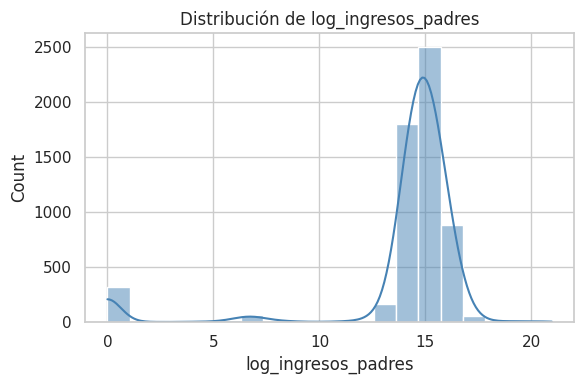

In [68]:
import numpy as np
import pandas as pd

# Transformación logarítmica de ingresos

df["log_ingresos_padres"] = np.log1p(df["Total ingresos padres"])
plt.figure(figsize=(6,4))
sns.histplot(df["log_ingresos_padres"], kde=True, bins=20, color="steelblue")
plt.title("Distribución de log_ingresos_padres")
plt.tight_layout()
plt.show()

Dependecia economica per capita




/tmp/ipython-input-3971491098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Resultado Final", y="dependencia_economica", data=df, palette="Set2")


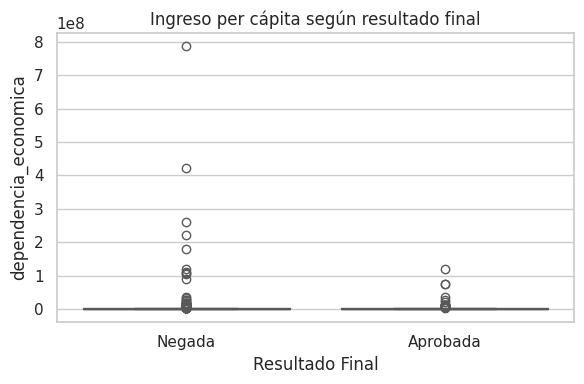

In [69]:

df["dependencia_economica"] = df["Total ingresos padres"] / df["Con cuántas personas vives actualmente"]
plt.figure(figsize=(6,4))
sns.boxplot(x="Resultado Final", y="dependencia_economica", data=df, palette="Set2")
plt.title("Ingreso per cápita según resultado final")
plt.tight_layout()
plt.show()

# Indicador de Notas (ICFES + Notas)

El indicador académico integra el desempeño del aspirante tanto en su trayectoria escolar (notas de 10° y 11°) como en las pruebas Saber 11 (ICFES), asignando un máximo de 35 puntos.

De estos, 20 puntos corresponden al rendimiento en materias fundamentales —transformadas y normalizadas según la escala institucional— y 15 puntos a los resultados del ICFES, ajustados al régimen de calificación vigente (2006–2014 o 2015 en adelante).

Este indicador sintetiza la capacidad académica previa del aspirante y permite comparar de forma homogénea cohortes con diferentes sistemas de evaluación, constituyéndose en una variable predictiva clave dentro del modelo de selección de becarios.

In [74]:
import numpy as np
import pandas as pd

# Materias
COLS_MATERIAS = [
    "Física 10°", "Física 11°",
    "Química 10°", "Química 11°",
    "Matemáticas 10°", "Matemáticas 11°",
    "Lenguaje/Español 10°", "Lenguaje/Español 11°"
]

# Solo las que existan realmente en el DataFrame
COLS_MATERIAS = [c for c in COLS_MATERIAS if c in df.columns]
if not COLS_MATERIAS:
    raise ValueError("No encontré columnas de materias con esos nombres. Revisa los encabezados.")

# Puntos
# Rangos en escala 0–5 -> Puntos
RANGOS_0A5 = [
    (4.5,   5.01, 20),  # ≥ 4.5
    (4.0,   4.5,  18),  # [4.0, 4.49]
    (3.6,   4.0,  15),  # [3.6, 3.99]
    (3.4,   3.6,  10),  # [3.4, 3.59]
    (3.0,   3.4,   5),  # [3.0, 3.39]
    (-np.inf, 3.0, 0),  # < 3.0
]

# Mapeo cualitativo -> puntos
MAPA_CUALITATIVO = {
    "superior": 20,
    "alto": 18,
    "alto/sobresaliente": 18,
    "sobresaliente": 18,
    "básico": 10, "basico": 10,
    "básico (puntaje 10)": 10, "basico (puntaje 10)": 10,
    "bajo": 0,
}

# Normalización
def _to_float_es(x):
    """Convierte strings con coma decimal a float. Devuelve NaN si no es numérico."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

def _normalizar_a_0_5(x):

    v = _to_float_es(x)
    if pd.isna(v):
        return np.nan
    return v / 2.0 if v > 5.5 else v

def _puntos_por_valor_0a5(v):

    if pd.isna(v):
        return np.nan
    for lo, hi, pts in RANGOS_0A5:
        if lo <= v < hi:
            return pts
    return np.nan

def _puntos_por_cualitativo(x):
    if pd.isna(x):
        return np.nan
    key = str(x).strip().lower()
    return MAPA_CUALITATIVO.get(key, np.nan)

def _puntuar_celda(x):

    v = _to_float_es(x)
    if not pd.isna(v):
        return _puntos_por_valor_0a5(_normalizar_a_0_5(v))
    # si no es numérico: intenta cualitativo
    return _puntos_por_cualitativo(x)

# Crear columnas de puntos por materia
pts_cols = []
for c in COLS_MATERIAS:
    c_pts = f"{c}_pts"
    df[c_pts] = df[c].apply(_puntuar_celda)
    pts_cols.append(c_pts)

# Promedio de puntos de materias

df["puntos_promedio_materias"] = df[pts_cols].mean(axis=1, skipna=True)

# Materias válidas tuvo cada fila:
df["materias_con_puntaje"] = df[pts_cols].notna().sum(axis=1)

# Revisión
cols_show = COLS_MATERIAS + pts_cols + ["puntos_promedio_materias", "materias_con_puntaje"]
display(df[cols_show].head(10))



,Física 10°,Física 11°,Química 10°,Química 11°,Matemáticas 10°,Matemáticas 11°,Lenguaje/Español 10°,Lenguaje/Español 11°,Física 10°_pts,Física 11°_pts,Química 10°_pts,Química 11°_pts,Matemáticas 10°_pts,Matemáticas 11°_pts,Lenguaje/Español 10°_pts,Lenguaje/Español 11°_pts,puntos_promedio_materias,materias_con_puntaje
0,4.00,3.90,4.00,3.90,3.70,4.50,4.50,4.70,18.0,15.0,18.0,15.0,15.0,20.0,20.0,20.0,17.625,8
1,3.90,3.70,3.90,3.70,4.00,3.90,3.90,4.10,15.0,15.0,15.0,15.0,18.0,15.0,15.0,18.0,15.750,8
2,4.02,3.81,3.92,3.93,3.77,4.16,4.18,4.29,18.0,15.0,15.0,15.0,15.0,18.0,18.0,18.0,16.500,8
3,4.60,4.20,4.00,4.40,4.20,4.10,3.90,3.70,20.0,18.0,18.0,18.0,18.0,18.0,15.0,15.0,17.500,8
4,3.70,4.00,3.70,4.00,4.10,3.70,4.20,4.60,15.0,18.0,15.0,18.0,18.0,15.0,18.0,20.0,17.125,8
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,NaN,3.90,NaN,3.62,NaN,3.80,NaN,3.61,NaN,15.0,NaN,15.0,NaN,15.0,NaN,15.0,15.000,4
7,3.90,4.80,3.70,4.90,4.00,4.80,3.50,5.00,15.0,20.0,15.0,20.0,18.0,20.0,10.0,20.0,17.250,8
8,3.60,3.80,3.90,4.10,4.00,3.60,4.40,4.40,15.0,15.0,15.0,18.0,18.0,15.0,18.0,18.0,16.500,8
9,4.50,4.50,4.00,3.20,4.00,5.00,4.50,5.00,20.0,20.0,18.0,5.0,18.0,20.0,20.0,20.0,17.625,8


,Puntaje ICFES,Año ICFES,icfes_score,icfes_year,icfes_regimen,icfes_rango,puntos_icfes,puntos_icfes_int
0,313.0,2021.0,313.0,2021.0,2015 en adelante,310–330,7.0,7
1,340.0,2023.0,340.0,2023.0,2015 en adelante,331–359,11.0,11
2,319.0,2020.0,319.0,2020.0,2015 en adelante,310–330,7.0,7
3,347.0,2022.0,347.0,2022.0,2015 en adelante,331–359,11.0,11
4,312.0,2020.0,312.0,2020.0,2015 en adelante,310–330,7.0,7
5,372.0,2004.0,372.0,2004.0,2006–2014,Superior a 72,15.0,15
6,317.0,2023.0,317.0,2023.0,2015 en adelante,310–330,7.0,7
7,374.0,2023.0,374.0,2023.0,2015 en adelante,≥360,15.0,15
8,350.0,2023.0,350.0,2023.0,2015 en adelante,331–359,11.0,11
9,216.0,2023.0,216.0,2023.0,2015 en adelante,<300,0.0,0



Distribución de rangos ICFES:
        icfes_regimen    icfes_rango  puntos_icfes_int     n
3          2006–2014            <60                 0    44
0          2006–2014          60–61                 3     4
1          2006–2014          62–65                 7     6
2          2006–2014          66–71                11     1
4          2006–2014  Superior a 72                15   143
8   2015 en adelante           <300                 0   376
5   2015 en adelante        300–309                 3   788
6   2015 en adelante        310–330                 7  1543
7   2015 en adelante        331–359                11  1871
9   2015 en adelante           ≥360                15  1055
10               NaN            NaN              <NA>    59


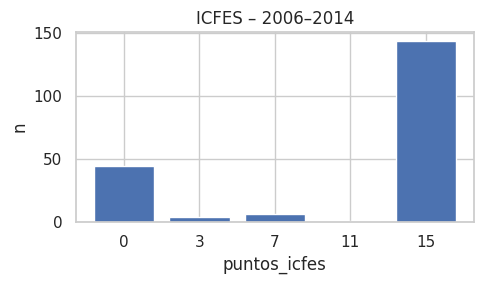

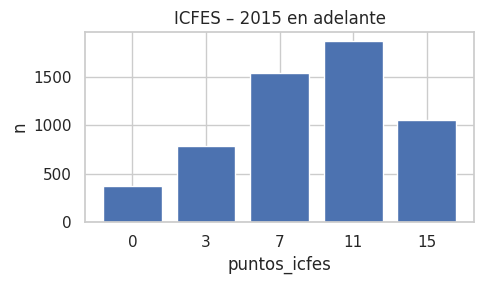

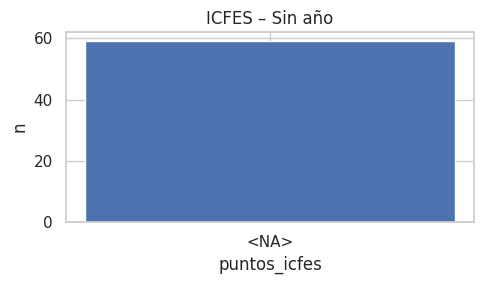

In [86]:
#Puntos por ICFES (robusto a cualitativos y sin np.where)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Limpieza y estandarización
def _to_number(x):

    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).strip()
    if not re.search(r"\d", s):
        return np.nan
    s = s.replace(",", ".")
    s = "".join(ch for ch in s if ch.isdigit() or ch in ".-")
    try:
        return float(s)
    except:
        return np.nan

df["icfes_score"] = df["Puntaje ICFES"].apply(_to_number)
df["icfes_year"]  = pd.to_numeric(df["Año ICFES"], errors="coerce")

# Diferencia por año
df["icfes_regimen"] = pd.Series(pd.NA, index=df.index, dtype="object")
df.loc[df["icfes_year"].le(2014), "icfes_regimen"] = "2006–2014"
df.loc[df["icfes_year"].ge(2015), "icfes_regimen"] = "2015 en adelante"

# Regla según año
# 2006–2014
mask_old = df["icfes_regimen"].eq("2006–2014")
s_old = df.loc[mask_old, "icfes_score"]

conds_o = [
    s_old > 72,
    (s_old >= 66) & (s_old <= 71),
    (s_old >= 62) & (s_old <= 65),
    (s_old >= 60) & (s_old <= 61),
]
vals_o  = [15, 11, 7, 3]
labs_o  = ["Superior a 72", "66–71", "62–65", "60–61"]

# 2015+ (puntajes 300–360)
mask_new = df["icfes_regimen"].eq("2015 en adelante")
s_new = df.loc[mask_new, "icfes_score"]

conds_n = [
    s_new >= 360,
    (s_new >= 331) & (s_new <= 359),
    (s_new >= 310) & (s_new <= 330),
    (s_new >= 300) & (s_new <= 309),
]
vals_n  = [15, 11, 7, 3]
labs_n  = ["≥360", "331–359", "310–330", "300–309"]

# Resultados
df["puntos_icfes"] = np.nan
df["icfes_rango"]  = pd.Series(pd.NA, index=df.index, dtype="object")

# Aplica reglas
df.loc[mask_old, "puntos_icfes"] = np.select(conds_o, vals_o, default=0)
df.loc[mask_old, "icfes_rango"]  = np.select(conds_o, labs_o, default="<60")

df.loc[mask_new, "puntos_icfes"] = np.select(conds_n, vals_n, default=0)
df.loc[mask_new, "icfes_rango"]  = np.select(conds_n, labs_n, default="<300")

# (Opcional) versión entera nullable para reportes
df["puntos_icfes_int"] = (
    pd.to_numeric(df["puntos_icfes"], errors="coerce").round().astype("Int64")
)

# Vista de control
cols_show = [
    "Puntaje ICFES","Año ICFES","icfes_score","icfes_year",
    "icfes_regimen","icfes_rango","puntos_icfes","puntos_icfes_int"
]
display(df[cols_show].head(12))

# Distribución para validar
dist = (
    df.groupby(["icfes_regimen","icfes_rango","puntos_icfes_int"], dropna=False)
      .size().reset_index(name="n")
      .sort_values(["icfes_regimen","puntos_icfes_int","icfes_rango"])
)
print("\nDistribución de rangos ICFES:\n", dist)

# Gráfico
tmp = (
    df.groupby(["icfes_regimen","puntos_icfes_int"], dropna=False)
      .size().reset_index(name="n")
      .sort_values(["icfes_regimen","puntos_icfes_int"])
)
for regimen, sub in tmp.groupby("icfes_regimen", dropna=False):
    plt.figure(figsize=(5,3))
    x = sub["puntos_icfes_int"].astype("Int64").astype(str)
    plt.bar(x, sub["n"])
    ttl = "ICFES – " + (regimen if pd.notna(regimen) else "Sin año")
    plt.title(ttl)
    plt.xlabel("puntos_icfes")
    plt.ylabel("n")
    plt.tight_layout()
    plt.show()


Cobertura indicador académico:
fuente_academica
Notas+ICFES    5831
Solo Notas       59
Name: count, dtype: int64

% filas con al menos una fuente: 100.0 %
% filas con ambas fuentes: 99.0 %


/tmp/ipython-input-3569271211.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["puntos_notas_num"] = pd.to_numeric(df[src_notas_col], errors="coerce")
/tmp/ipython-input-3569271211.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["puntos_icfes_num"] = pd.to_numeric(df["puntos_icfes"], errors="coerce")
/tmp/ipython-input-3569271211.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

,Puntos_notas,puntos_notas_num,Puntaje ICFES,Año ICFES,puntos_icfes_num,puntos_academicos,puntos_academicos_int,fuente_academica
0,15.0,15.0,313.0,2021.0,7.0,22.0,22,Notas+ICFES
1,15.0,15.0,340.0,2023.0,11.0,26.0,26,Notas+ICFES
2,15.0,15.0,319.0,2020.0,7.0,22.0,22,Notas+ICFES
3,15.0,15.0,347.0,2022.0,11.0,26.0,26,Notas+ICFES
4,15.0,15.0,312.0,2020.0,7.0,22.0,22,Notas+ICFES
5,15.0,15.0,372.0,2004.0,15.0,30.0,30,Notas+ICFES
6,10.0,10.0,317.0,2023.0,7.0,17.0,17,Notas+ICFES
7,25.0,25.0,374.0,2023.0,15.0,35.0,35,Notas+ICFES
8,20.0,20.0,350.0,2023.0,11.0,31.0,31,Notas+ICFES
9,10.0,10.0,216.0,2023.0,0.0,10.0,10,Notas+ICFES


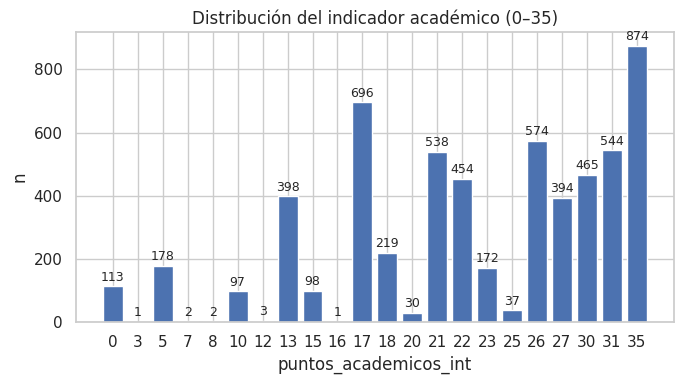

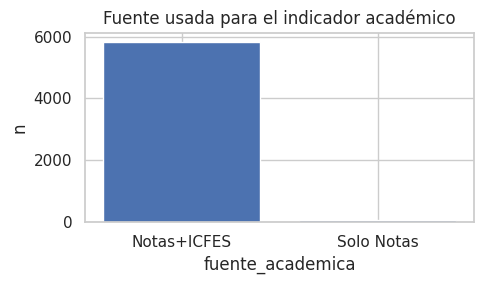

In [87]:
# Indicador académico (Materias/Notas + ICFES)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAX_PTS_NOTAS = 20
MAX_PTS_ICFES = 15
MAX_PTS_ACAD  = MAX_PTS_NOTAS + MAX_PTS_ICFES  # 35

# Fuente de puntos por notas

if "Puntos_notas" in df.columns:
    src_notas_col = "Puntos_notas"
elif "puntos_promedio_materias" in df.columns:
    src_notas_col = "puntos_promedio_materias"
else:
    # Si no hay ninguna, crea una columna nula
    src_notas_col = "Puntos_notas"
    df[src_notas_col] = np.nan

# Estandariza a numérico seguro (por si 'Puntos_notas' viene como texto)
df["puntos_notas_num"] = pd.to_numeric(df[src_notas_col], errors="coerce")


if "puntos_icfes" not in df.columns:
    df["puntos_icfes"] = np.nan
df["puntos_icfes_num"] = pd.to_numeric(df["puntos_icfes"], errors="coerce")

#Suma de puntos
df["puntos_academicos"] = df[["puntos_notas_num","puntos_icfes_num"]].sum(axis=1, min_count=1)

# Limita por seguridad a [0, 35]
df.loc[df["puntos_academicos"] < 0, "puntos_academicos"] = 0
df.loc[df["puntos_academicos"] > MAX_PTS_ACAD, "puntos_academicos"] = MAX_PTS_ACAD

# Versión entera nullable para reportes/tablas
df["puntos_academicos_int"] = pd.to_numeric(df["puntos_academicos"], errors="coerce").round().astype("Int64")

# Metadatos de cobertura
df["has_notas"] = df["puntos_notas_num"].notna()
df["has_icfes"] = df["puntos_icfes_num"].notna()
df["fuente_academica"] = np.select(
    [
        df["has_notas"] & df["has_icfes"],
        df["has_notas"] & ~df["has_icfes"],
        ~df["has_notas"] & df["has_icfes"],
    ],
    ["Notas+ICFES", "Solo Notas", "Solo ICFES"],
    default="Sin datos"
)

# Chequeos rápidos
tot_rows = len(df)
print("Cobertura indicador académico:")
print(df["fuente_academica"].value_counts(dropna=False))
print("\n% filas con al menos una fuente:", (df["puntos_academicos"].notna().mean()*100).round(2), "%")
print("% filas con ambas fuentes:", ((df["has_notas"] & df["has_icfes"]).mean()*100).round(2), "%")

# Vista de control
cols_show = [
    src_notas_col, "puntos_notas_num",
    "Puntaje ICFES", "Año ICFES", "puntos_icfes_num",
    "puntos_academicos", "puntos_academicos_int", "fuente_academica"
]
display(df[cols_show].head(12))

# Distribuciones

conteos = df["puntos_academicos_int"].value_counts(dropna=False).sort_index()
# Etiquetas reemplazando <NA> por 'Sin dato'
labels = [("Sin dato" if (pd.isna(x)) else str(int(x))) for x in conteos.index]

plt.figure(figsize=(7,4))
plt.bar(labels, conteos.values)
plt.title("Distribución del indicador académico (0–35)")
plt.xlabel("puntos_academicos_int")
plt.ylabel("n")
for i, v in enumerate(conteos.values):
    plt.text(i, v + max(conteos.values)*0.01, f"{int(v)}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Desglose por fuente
src_counts = df["fuente_academica"].value_counts(dropna=False)
plt.figure(figsize=(5,3))
plt.bar(src_counts.index.astype(str), src_counts.values)
plt.title("Fuente usada para el indicador académico")
plt.xlabel("fuente_academica")
plt.ylabel("n")
plt.tight_layout()
plt.show()


# 12.6 Selección final de variables para el modelado

Se definió el conjunto de datos final para el modelado predictivo, consolidando las variables limpias y derivadas en un nuevo DataFrame (df_model).

In [91]:
import pandas as pd

# Variable objetivo
target = "Resultado Final"

# Variables académicas
vars_academicas = [
    "puntos_academicos",          # Indicador total (0–35)
    "puntos_notas_num",           # Desempeño en notas 10°–11°
    "puntos_icfes_num",           # Puntaje transformado Saber 11
    "Tipo colegio",               # Pública / Privada
]

# Variables socioeconómicas
vars_socioeco = [
    "Total ingresos padres",      # ingreso total familiar
    "Con cuántas personas vives actualmente",
    "prof_padre_es_profesional",  # creada en ingeniería
    "prof_madre_es_profesional",  # creada en ingeniería
    "num_inmuebles",              # conteo casas, apartamentos, etc.
    "tiene_inmuebles",            # 0/1 si posee propiedades
    "Tipo vivienda",              # Propia / Arrendada / Familiar
    "Estrato",                    # socioeconómico
]

# Variables demográficas
vars_demo = [
    "Edad al postularse",
    "Sexo biológico",
    "Dpto de Residencia",
]

# Consolidación de variables seleccionadas
variables_finales = (
    [target] +
    vars_academicas +
    vars_socioeco +
    vars_demo
)

# Filtrar solo las columnas existentes (algunas pueden variar según el semestre)
cols_presentes = [c for c in variables_finales if c in df.columns]
df_model = df[cols_presentes].copy()

print(f"Variables incluidas en el modelo: {len(cols_presentes)} columnas")
for v in cols_presentes:
    print(" -", v)

# Limpieza final

for col in ["puntos_academicos", "puntos_notas_num", "puntos_icfes_num",
            "Total ingresos padres", "Con cuántas personas vives actualmente",
            "num_inmuebles"]:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Normalización
for col in ["Tipo colegio", "Tipo vivienda", "Sexo biológico", "Dpto de Residencia"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.strip().str.upper()

# Añadir ID anonimizado
df_model.insert(0, "ID_anon", range(1, len(df_model) + 1))

#Exportar a Excel
nombre_archivo = "df_model.xlsx"
df_model.to_excel(nombre_archivo, index=False)

print(f"Dimensiones finales: {df_model.shape}")
print(f"Primeras columnas: {list(df_model.columns)[:5]}")


Variables incluidas en el modelo: 12 columnas
 - Resultado Final
 - puntos_academicos
 - puntos_notas_num
 - puntos_icfes_num
 - Tipo colegio
 - Total ingresos padres
 - Con cuántas personas vives actualmente
 - Tipo vivienda
 - Estrato
 - Edad al postularse
 - Sexo biológico
 - Dpto de Residencia
Dimensiones finales: (5890, 13)
Primeras columnas: ['ID_anon', 'Resultado Final', 'puntos_academicos', 'puntos_notas_num', 'puntos_icfes_num']
